# Molecular Dynamics Analysis of the Prion Protein (PrP)

## Pipeline for Amyloidogenic Mutation Assessment

This notebook is designed to analyze Molecular Dynamics (MD) trajectories of the Prion Protein (PrP), specifically comparing the Wild-Type (WT) against point mutations within the target amyloidogenic region.

**Author:** Bioinformatics Institute, St. Petersburg  
**Date:** Spring 2026  
**Prerequisites:** A completed GROMACS production trajectory of PrP in CHARMM36m / CHARMM-TIP3P / 150 mM NaCl.

### Background & Biological Context
Unlike purely intrinsically disordered proteins (IDPs) such as Aβ42, the mature Prion Protein (residues 23-231) contains a highly structured C-terminal domain consisting of three α-helices and a short anti-parallel β-sheet. 

The region of specific interest in this project is **residues 170-193**. This segment is known to play a critical role in the pathological conversion from the native cellular form (PrP^C) to the misfolded, aggregation-prone scrapie form (PrP^Sc). 

### Content
1.  **System Validation:** Load the MD trajectory and correct the structural numbering to match the standard biological literature for PrP.
    * Load and validate a GROMACS trajectory in MDAnalysis
2.  **Structural Observables:** Evaluate global stability and local flexibility (RMSD, RMSF, Rg) to determine if a point mutation destabilizes the native fold.
    * Compute structural observables (RMSD, RMSF, Rg, end-to-end distance)
    * Analyse **intramolecular** hydrogen bonds (not protein–water)
    * Measure prion-specific order parameters: Cys179-Cys214 disulfide bridge, Helix2-3 distance
    * Build contact maps and contact frequency matrices
3.  **Local Dynamics:** Analyze secondary structure elements specifically around the target amyloidogenic region to identify mechanisms of disruption or aggregation.
    * Track secondary structure over time with the built-in DSSP module
    * Run Principal Component Analysis and interpret cosine content as a convergence diagnostic
    * Assess whether your simulation has converged

### How to use this notebook

- **Theory cells** (markdown) explain the physics behind each analysis step
- **Code cells** are ready to run — just update the file paths in Section 1
- **🔍 Interpretation** blocks ask you to examine results and write answers directly in the cell

### Critical unit convention

> **MDAnalysis uses Ångströms (Å) for all distances and picoseconds (ps) for time.** This is different from GROMACS (nm, ps). When comparing to literature, convert: `value_nm = value_A / 10`.

---
## 0. Prerequisites and Environment Check

Before we begin, let's verify that all required packages are installed and at correct versions.

In [1]:
# ============================================================
# 0. PREREQUISITES CHECK
# ============================================================
# If any import fails: pip install MDAnalysis matplotlib seaborn pandas scipy numpy
import os
import sys
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import MDAnalysis as mda
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import correlate
from MDAnalysis.analysis import rms, align, distances, pca
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

# ---- Publication-quality plot settings ----
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.linewidth": 0.8, "axes.labelsize": 11,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.major.size": 3.5, "ytick.major.size": 3.5,
    "legend.frameon": False, "figure.dpi": 150,
    "savefig.dpi": 300, "savefig.bbox": "tight"
})

print(f"MDAnalysis version: {mda.__version__}")
assert int(mda.__version__.split('.')[0]) >= 2, "MDAnalysis >= 2.0 required"
print(f"NumPy version:      {np.__version__}")
print("✅ All imports successful")


/home/ser/miniforge3/envs/md_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MDAnalysis version: 2.9.0
NumPy version:      2.2.6
✅ All imports successful


---
## 1. Loading and Validating the Trajectory

### Theory: The MDAnalysis `Universe`

MDAnalysis organises simulation data into a `Universe` object that combines a **topology** file (`.tpr`, `.gro`, `.pdb`) with one or more **trajectory** files (`.xtc`, `.trr`, `.dcd`). The `Universe` reads one frame at a time — essential for multi-GB files.
To get pdb topology file, run the following step:
```bash
gmx trjconv -s md.tpr -f md.xtc -dump 0 -o prp_wt_md.pdb
```

### Before loading: PBC correction

Your trajectory **must** be pre-processed to remove periodic boundary condition artifacts:

```bash
gmx trjconv -f md.xtc -s md.tpr -pbc whole -o step1.xtc
gmx trjconv -f step1.xtc -s md.tpr -pbc nojump -o step2.xtc
gmx trjconv -f step2.xtc -s md.tpr -pbc mol -center -ur compact -o md_clean.xtc
```

Without this, `radius_of_gyration()` and distance calculations will give **wrong results**.


### AlphaFold3 numeration correction

The initial structures predicted by tools like AlphaFold3 often start their internal residue numbering from 1. For PrP, the structural core we have simulated started at residue 124 (after the cleavage of the 22-amino-acid N-terminal signal peptide and unstructured N-terminal domain). 

We apply a specific `RESIDUE_OFFSET` to correct this numbering in the MDAnalysis Universe. In the outputs below, verify that the "Corrected biological residue range" aligns with the standard PrP sequence (e.g., starting at 125). This ensures all subsequent selections for our target region (170-193) are biologically accurate.

In [4]:
# ============================================================
# 1. LOAD YOUR TRAJECTORY AND CONFIGURE PIPELINE
# ============================================================
# --- Pipeline Configuration ---
# Set the mutation name ('WT' or 'V180R') to dynamically update titles, paths, and plots
MUTATION_NAME = "V180R"

# Relative paths
TOPOLOGY_PATH = f"../structures/prp_{MUTATION_NAME}.tpr"
TRAJECTORY_PATH = f"../structures/trajectory_{MUTATION_NAME}.xtc"

# AlphaFold3 shift correction: the trimmed structural core (residues 125-228) 
# starts from index 1 in the PDB file. To restore biological numbering, we add 124.
RESIDUE_OFFSET = 124

# Target amyloidogenic region defined in biological numbering
TARGET_START = 170
TARGET_END = 193


In [13]:
print(f"Initializing MDAnalysis Universe for: {MUTATION_NAME}")
print(f"Loading topology:   {TOPOLOGY_PATH}")
print(f"Loading trajectory: {TRAJECTORY_PATH}\n")

# Load the system
u = mda.Universe(TOPOLOGY_PATH, TRAJECTORY_PATH)

protein = u.select_atoms("protein")

print(print(f"Original PDB residue range: {protein.residues.resids[0]} to {protein.residues.resids[-1]}"))

# Apply the offset to modify the coordinates in-place to biological numbering
u.atoms.residues.resids += RESIDUE_OFFSET

print(f"Corrected biological residue range: {protein.residues.resids[0]} to {protein.residues.resids[-1]}")

Initializing MDAnalysis Universe for: V180R
Loading topology:   ../structures/prp_V180R.tpr
Loading trajectory: ../structures/trajectory_V180R.xtc

Original PDB residue range: 1 to 104
None
Corrected biological residue range: 125 to 228


In [6]:
ca = u.select_atoms("protein and name CA")
n_atoms = len(u.atoms)
n_frames = u.trajectory.n_frames
dt_ps = u.trajectory.dt
total_ns = u.trajectory.totaltime / 1000

print("--- Trajectory Sanity Check ---")
print(f"Total number of atoms in system: {n_atoms}")
print(f"Total number of frames loaded:   {n_frames}")
print(f"Trajectory timestep:             {u.trajectory.dt} ps")
print(f"Total simulation time:           {n_frames * u.trajectory.dt / 1000.0} ns")

--- Trajectory Sanity Check ---
Total number of atoms in system: 29873
Total number of frames loaded:   16001
Trajectory timestep:             10.0 ps
Total simulation time:           160.01 ns


In [7]:
# Define standard atom selections using corrected biological numbering
protein = u.select_atoms("protein")
backbone_all = u.select_atoms("backbone")
target_region = u.select_atoms(f"resid {TARGET_START}:{TARGET_END}")

print("--- Atom Selections Successful ---")
print(f"Protein atoms selected:       {len(protein)}")
print(f"Backbone atoms selected:      {len(backbone_all)}")
print(f"Target region atoms ({TARGET_START}-{TARGET_END}): {len(target_region)}")

# Verify residue count
expected_count = 104  # for PrP(125-228)
assert ca.n_residues == expected_count, \
    f"Expected {expected_count} residues, got {ca.n_residues}"
print(f"✅ Correct residue count ({expected_count})")

--- Atom Selections Successful ---
Protein atoms selected:       1702
Backbone atoms selected:      415
Target region atoms (170-193): 377
✅ Correct residue count (104)


In [8]:
# Many analyses (RMSF, PCA) require alignment to remove
# overall translation and rotation.
from MDAnalysis.analysis import align, rms

print(f"Aligning trajectory for {MUTATION_NAME}...")

ref = mda.Universe(TOPOLOGY_PATH, TRAJECTORY_PATH)
ref.atoms.residues.resids += RESIDUE_OFFSET

aligner = align.AlignTraj(u, ref, select="protein and name CA", in_memory=True)
aligner.run()

# Create a time axis we will reuse throughout
time_ns = np.arange(n_frames) * dt_ps / 1000
resids = ca.resids

print("Alignment completed successfully.\n")

Aligning trajectory for V180R...
Alignment completed successfully.



## Structural Observables (RMSD, RMSF, Rg)

This section evaluates the overall structural integrity of the protein over the course of the simulation. Because PrP has a well-defined folded domain, these classic metrics are highly informative and provide the first clues about the mutation's impact.

## 2. Root Mean Square Deviation (RMSD)
* **Purpose:** Measures how much the protein's backbone deviates from its initial starting structure over time.
* **Interpretation for PrP:** A stable, folded PrP will show an initial rapid rise in RMSD and then reach a plateau (convergence). If the RMSD continues to climb or fluctuates wildly, the protein is unfolding or undergoing a major slow conformational shift. By calculating RMSD for both the global backbone and the target region (170-193), we can identify if the mutation specifically destabilizes the amyloidogenic core without necessarily breaking the entire protein.

$$\text{RMSD}(t) = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \left| \mathbf{r}_i(t) - \mathbf{r}_i^{\text{ref}} \right|^2 }$$


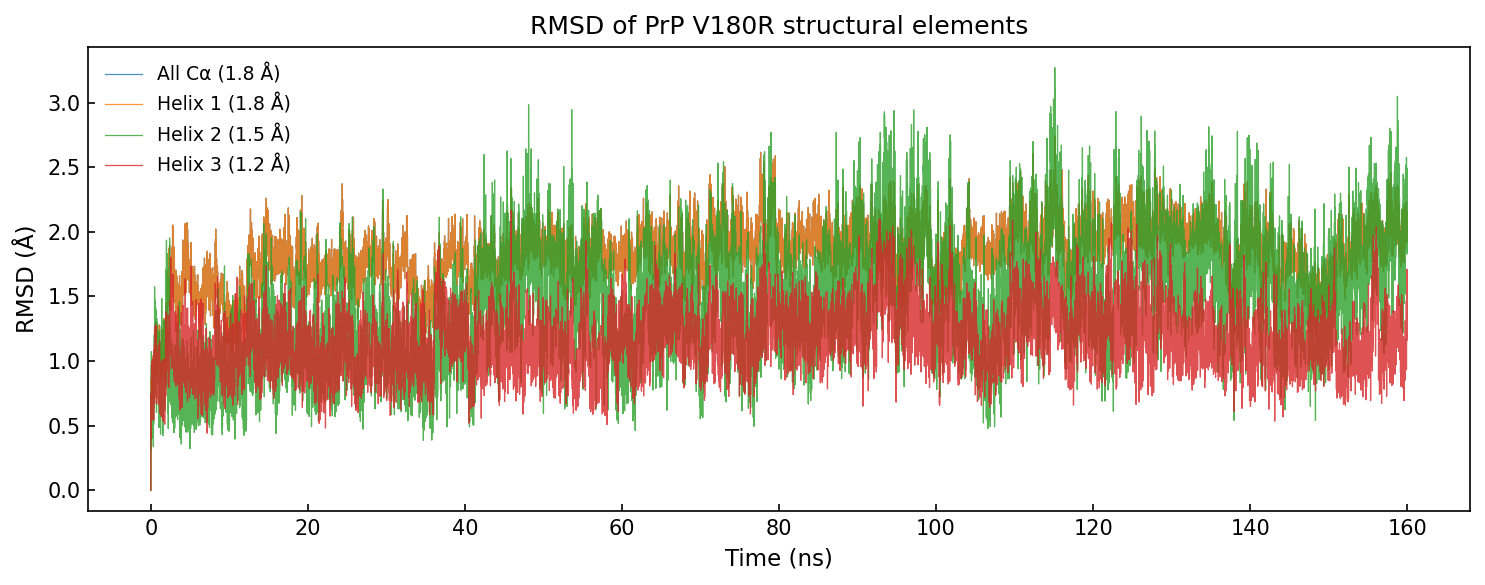

In [9]:
# ============================================================
# 2. RMSD ANALYSIS
# ============================================================
R = rms.RMSD(u, ref,
             select="protein and name CA",
             groupselections=[
                 "protein and name CA",         # all Cα
                 "resid 144:154 and name CA",   # Helix 1
                 "resid 173:194 and name CA",   # Helix 2
                 "resid 200:228 and name CA",   # Helix 3
             ])
R.run()

rmsd_time = R.results.rmsd[:, 1] / 1000    # ps → ns
rmsd_all = R.results.rmsd[:, 2]            # Å
rmsd_h1 = R.results.rmsd[:, 3]             # Å
rmsd_h2 = R.results.rmsd[:, 4]             # Å
rmsd_h3 = R.results.rmsd[:, 5]             # Å

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rmsd_time, rmsd_all, lw=0.6, alpha=0.8, label=f"All Cα ({rmsd_all.mean():.1f} Å)")
ax.plot(rmsd_time, rmsd_h1,  lw=0.6, alpha=0.8, label=f"Helix 1 ({rmsd_h1.mean():.1f} Å)")
ax.plot(rmsd_time, rmsd_h2,  lw=0.6, alpha=0.8, label=f"Helix 2 ({rmsd_h2.mean():.1f} Å)")
ax.plot(rmsd_time, rmsd_h3,  lw=0.6, alpha=0.8, label=f"Helix 3 ({rmsd_h3.mean():.1f} Å)")

ax.set_xlabel("Time (ns)")
ax.set_ylabel("RMSD (Å)")
ax.set_title(f"RMSD of PrP {MUTATION_NAME} structural elements")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"../figures/01_rmsd_{MUTATION_NAME.lower()}.png", dpi=300)
plt.show()


---
## 3. Radius of Gyration (Rg)

* **Purpose:** Measures the mass-weighted spread of atoms around their centre of mass - the overall compactness of the protein structure.
* **Interpretation for PrP:** A constant, stable $R_g$ indicates that the protein remains tightly folded. A sudden or gradual increase in $R_g$ suggests the protein is swelling or partially unfolding, potentially exposing its hydrophobic core to the solvent.

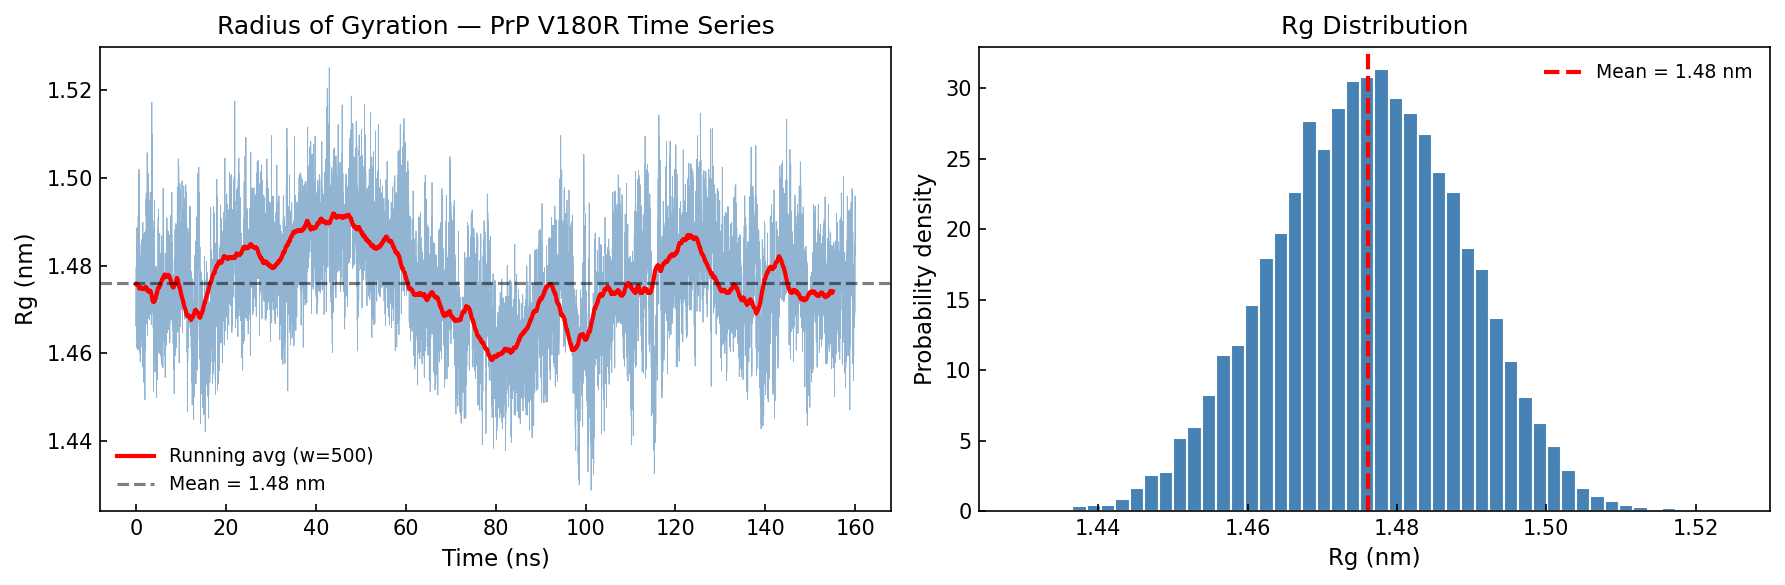

⟨Rg⟩ = 1.476 ± 0.013 nm


In [10]:
# ============================================================
# 3. RADIUS OF GYRATION
# ============================================================
rg_values = np.empty(n_frames)
for i, ts in enumerate(u.trajectory):
    rg_values[i] = protein.radius_of_gyration()   # Å

rg_nm = rg_values / 10.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Time series
axes[0].plot(time_ns, rg_nm, lw=0.4, alpha=0.6, color="steelblue")
window = min(500, n_frames // 5)
if window > 1:
    ravg = np.convolve(rg_nm, np.ones(window)/window, mode='valid')
    axes[0].plot(time_ns[:len(ravg)], ravg, lw=2, color="red", label=f"Running avg (w={window})")
axes[0].axhline(rg_nm.mean(), ls="--", color="black", alpha=0.5, label=f"Mean = {rg_nm.mean():.2f} nm")
axes[0].set_xlabel("Time (ns)"); axes[0].set_ylabel("Rg (nm)")
axes[0].set_title(f"Radius of Gyration — PrP {MUTATION_NAME} Time Series"); axes[0].legend(fontsize=9)

# Distribution
axes[1].hist(rg_nm, bins=50, density=True, color="steelblue", edgecolor="white")
axes[1].axvline(rg_nm.mean(), ls="--", color="red", lw=2, label=f"Mean = {rg_nm.mean():.2f} nm")
axes[1].set_xlabel("Rg (nm)"); axes[1].set_ylabel("Probability density")
axes[1].set_title("Rg Distribution"); axes[1].legend(fontsize=9)

plt.tight_layout(); plt.savefig(f"../figures/02_rg_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()
print(f"⟨Rg⟩ = {rg_nm.mean():.3f} ± {rg_nm.std():.3f} nm")


### Radius of Gyration vs. End-to-End Distance

* **Purpose:** To understand global polymer dynamics by comparing the overall compactness ($R_g$) with the linear distance between the N-terminus and C-terminus.
* **Interpretation for PrP:** The mature Prion Protein (residues 23-231) has a unique architecture: a highly flexible, intrinsically disordered N-terminal tail (roughly residues 23-124) and a rigidly folded C-terminal domain (125-231). In this project, the disordered N-terminal tail was removed? so the End-to-End distance will not exhibit massive fluctuations. **Do not mistake such fluctuations for unfolding.** Instead, look for major shifts in the baseline. If an increase in $R_g$ strongly correlates with a permanent expansion of the End-to-End distance in the mutant trajectory, it may indicate that the mutation has disrupted the folded C-terminal core, causing the entire protein to adopt a more extended, thread-like conformation.

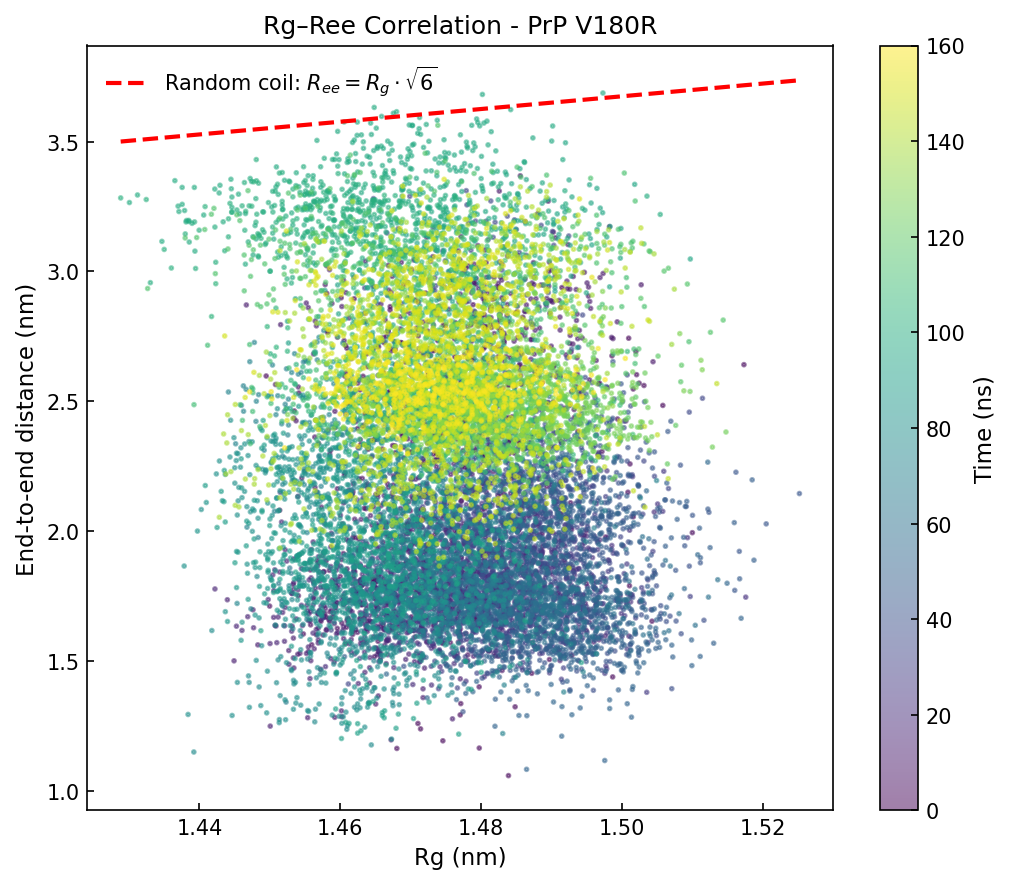

Pearson r(Rg, Ree) = -0.121 (p = 3.41e-53)


In [11]:
# ============================================================
# End-to-end distance
# ============================================================
n_term_ca = u.select_atoms("resid 125 and name CA")
c_term_ca = u.select_atoms("resid 228 and name CA")

ree_values = np.empty(n_frames)
for i, ts in enumerate(u.trajectory):
    ree_values[i] = np.linalg.norm(n_term_ca.positions[0] - c_term_ca.positions[0])
ree_nm = ree_values / 10.0

# ---- Rg vs Ree scatter ----
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(rg_nm, ree_nm, c=time_ns, cmap="viridis", s=3, alpha=0.5)
plt.colorbar(sc, ax=ax, label="Time (ns)")
rg_line = np.linspace(rg_nm.min(), rg_nm.max(), 50)
ax.plot(rg_line, rg_line * np.sqrt(6), "r--", lw=2,
        label=r"Random coil: $R_{ee} = R_g \cdot \sqrt{6}$")
ax.set_xlabel("Rg (nm)"); ax.set_ylabel("End-to-end distance (nm)")
ax.set_title(f"Rg–Ree Correlation - PrP {MUTATION_NAME}"); ax.legend()
plt.tight_layout(); plt.savefig(f"../figures/03_rg_vs_ree_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()

r_corr, p_val = stats.pearsonr(rg_nm, ree_nm)
print(f"Pearson r(Rg, Ree) = {r_corr:.3f} (p = {p_val:.2e})")


---
## 4. Root Mean Square Fluctuation (RMSF) — Per-Residue Flexibility

* **Purpose:** Measures the average flexibility of each individual amino acid over the trajectory.
* **Interpretation for PrP:** We expect sharp peaks in loop regions and the unstructured N-terminus, while the α-helices should have low RMSF values (valleys). Look closely at the highlighted target region (170-193). If the mutation causes a significant increase in RMSF in this region compared to the Wild-Type, it suggests the amyloidogenic segment has become more exposed and flexible, which can alter its aggregation propensity.

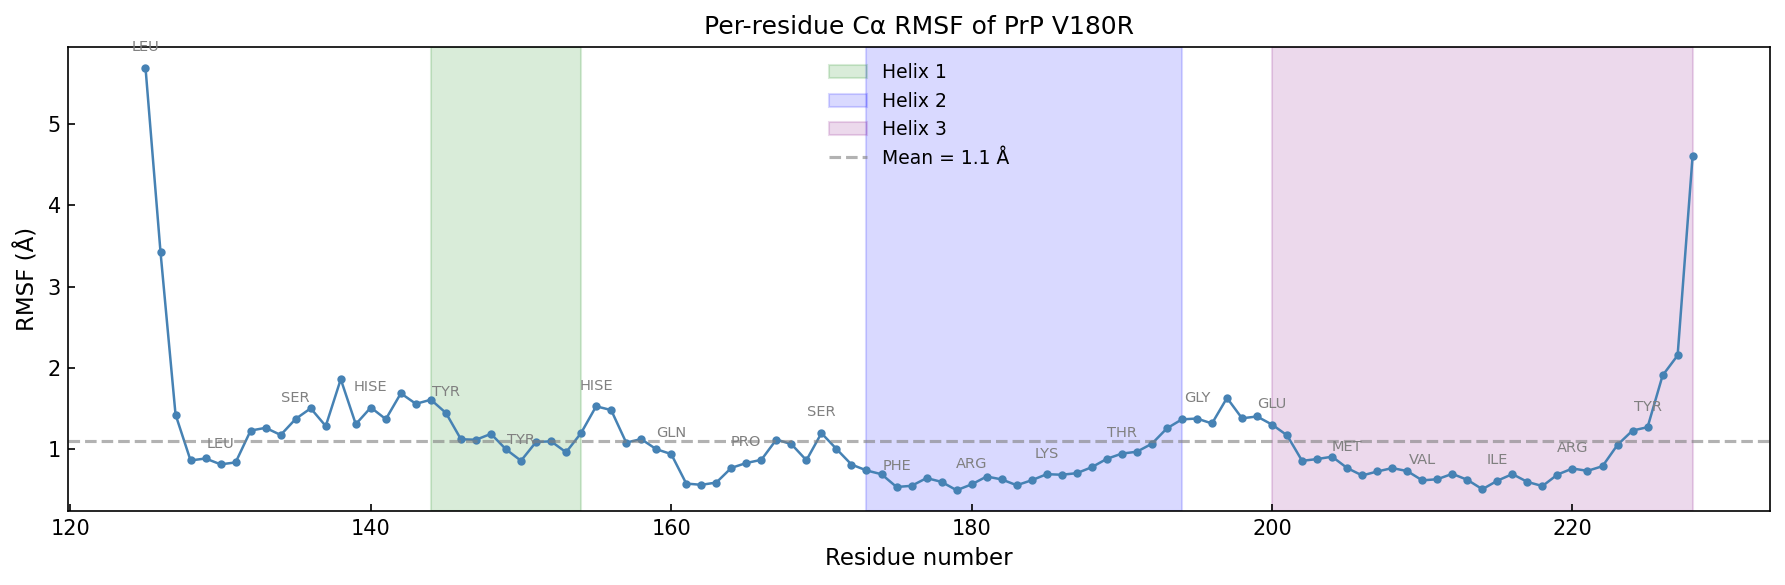

In [12]:
calphas = u.select_atoms("protein and name CA")
rmsf_calc = rms.RMSF(calphas).run()
rmsf_A = rmsf_calc.results.rmsf

resnames = [r.resname for r in calphas.residues]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(resids, rmsf_A, "o-", color="steelblue", markersize=3, lw=1.2)

# Выделяем наши спирали (нумерация 126-228)
ax.axvspan(144, 154, alpha=0.15, color="green", label="Helix 1")
ax.axvspan(173, 194, alpha=0.15, color="blue", label="Helix 2")
ax.axvspan(200, 228, alpha=0.15, color="purple", label="Helix 3")

ax.axhline(rmsf_A.mean(), ls="--", color="gray", alpha=0.6, label=f"Mean = {rmsf_A.mean():.1f} Å")
ax.set_xlabel("Residue number")
ax.set_ylabel("RMSF (Å)")
ax.set_title(f"Per-residue Cα RMSF of PrP {MUTATION_NAME}")
ax.legend(fontsize=9)

for j in range(0, len(resids), 5):
    ax.annotate(resnames[j], xy=(resids[j], rmsf_A[j]),
                xytext=(0, 8), textcoords="offset points", fontsize=7, ha="center", color="gray")

plt.tight_layout()
plt.savefig(f"../figures/04_rmsf_{MUTATION_NAME.lower()}.png", dpi=300)
plt.show()


---
## 5. Secondary Structure Analysis (DSSP)

### Theory

MDAnalysis ≥ 2.4 includes a built-in DSSP module assigning three labels: `H` (helix), `E` (extended/β-strand), `-` (loop). We generate three views: per-residue propensity bar chart, time–residue heatmap, and β-sheet content time series.

**Expected for Aβ42 in water:** 60–80% coil, 10–25% β-sheet, < 10% helix (matching CD data).


## Section 3: Secondary Structure Evolution (DSSP)

MDAnalysis ≥ 2.4 includes a built-in Dictionary of Protein Secondary Structure (DSSP) module assigning secondary structure types (e.g., α-helix, β-sheet, turn, coil) to every residue for every frame of the simulation. This is arguably the most critical metric for evaluating prion mutations. We generate four views: per-residue propensity bar chart, time–residue heatmap, β-sheet content time series and helix content time series..

### Biological Context of PrP Conversion
The hallmark of prion disease is the massive structural transition of PrP from a predominantly α-helical native state (PrP^C) to a β-sheet-rich, insoluble, amyloidogenic state (PrP^Sc). Our target region (**residues 170-193**) encompasses a critical loop and a portion of Helix 2 (H2). 

### How to interpret the DSSP timeline:
1. **The Wild-Type Baseline:** In the WT simulation, you should observe stable blocks of α-helices (typically red/pink on the plot) in the C-terminal domain (H1, H2, H3), while the N-terminus remains a random coil (white/grey).
2. **The "Breaker" Effect:** Successful amyloidogenic breaker mutations (like introducing an Proline, which creates a sharp structural kink, or charged residues like R/E/K) are designed to disrupt the local propensity to form ordered cross-β structures. 
3. **What to look for:** Focus entirely on the `170-193` region on the y-axis. If the mutation is a successful breaker, you will see the native structural elements (like the start of Helix 2) "melt" into Turns or Random Coils compared to the WT. A local loss of ordered structure here is a strong indicator that the sequence can no longer act as a stable seed for amyloid aggregation. The homogeneity of the secondary structure over time itself can serve as an indirect sign of protein stability.

In [14]:
# ============================================================
# 5. DSSP SECONDARY STRUCTURE
# ============================================================
try:
    from MDAnalysis.analysis.dssp import DSSP
    dssp = DSSP(u).run()
    S_oh = dssp.results.dssp_ndarray   # (n_frames, n_residues, 3) = [coil, helix, sheet]
    dssp_available = True
    print("✅ Built-in DSSP loaded")
except (ImportError, AttributeError):
    print("⚠️  Built-in DSSP not available. Install: pip install pydssp")
    print("    Skipping DSSP sections (you can still run everything else).")
    S_oh = None
    dssp_available = False


✅ Built-in DSSP loaded


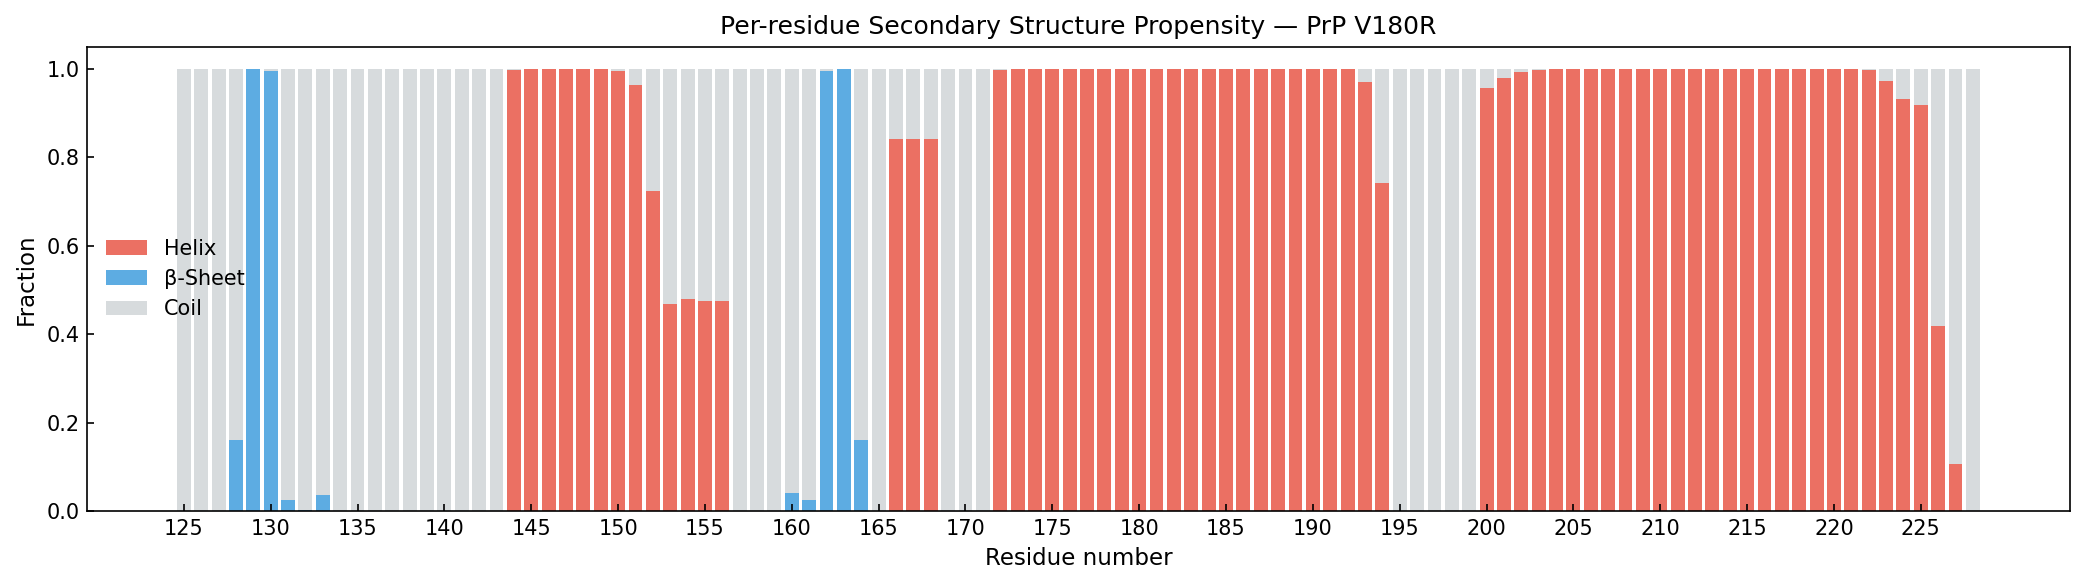

Overall Helix: 59.7% | Sheet: 4.3% | Coil: 36.0%


In [15]:
# ============================================================
# 5a. Per-residue secondary structure propensity
# ============================================================
if dssp_available:
    n_res_dssp = S_oh.shape[1]
    resids_dssp = resids[:n_res_dssp]

    coil_per_res  = S_oh[:, :, 0].mean(axis=0)
    helix_per_res = S_oh[:, :, 1].mean(axis=0)
    sheet_per_res = S_oh[:, :, 2].mean(axis=0)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(resids_dssp, helix_per_res, label="Helix", color="#E74C3C", alpha=0.8)
    ax.bar(resids_dssp, sheet_per_res, bottom=helix_per_res,
           label="β-Sheet", color="#3498DB", alpha=0.8)
    ax.bar(resids_dssp, coil_per_res, bottom=helix_per_res + sheet_per_res,
           label="Coil", color="#BDC3C7", alpha=0.6)
    
    ax.set_xlabel("Residue number")
    ax.set_ylabel("Fraction")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Per-residue Secondary Structure Propensity — PrP {MUTATION_NAME}")
    ax.legend(fontsize=10)
    ax.set_xticks(resids_dssp[::5])
    plt.tight_layout()
    plt.savefig(f"../figures/05a_dssp_propensity_{MUTATION_NAME.lower()}.png", dpi=300)
    plt.show()

    print(f"Overall Helix: {helix_per_res.mean()*100:.1f}% | "
          f"Sheet: {sheet_per_res.mean()*100:.1f}% | "
          f"Coil: {coil_per_res.mean()*100:.1f}%")

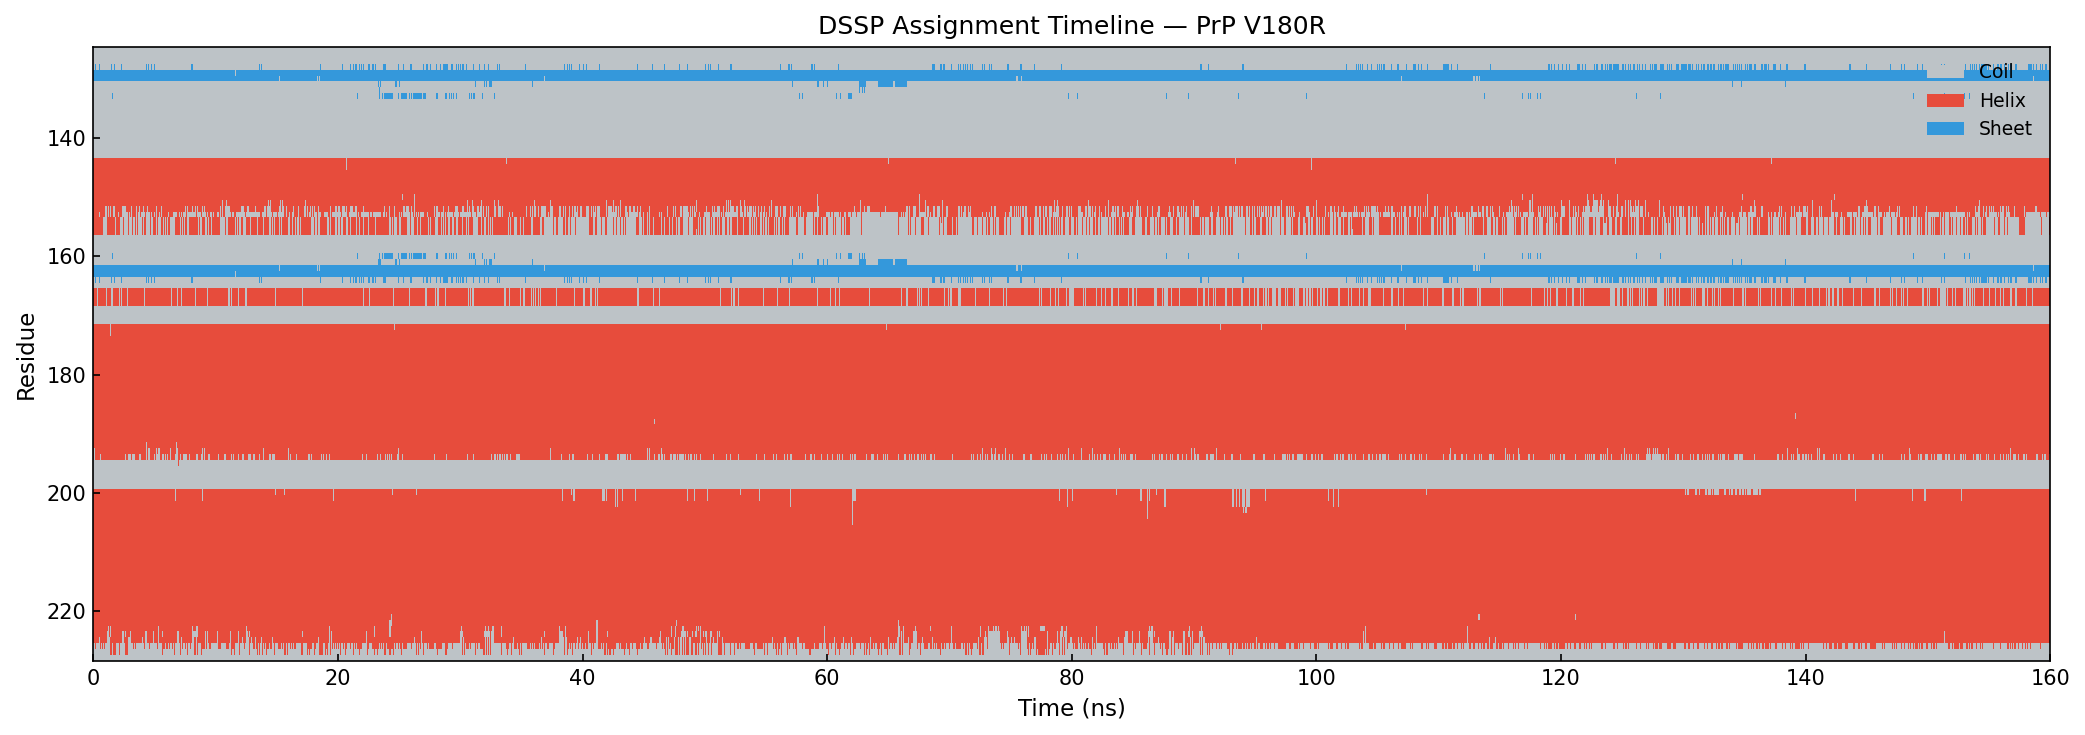

In [16]:
# ============================================================
# 5b. DSSP time-residue heatmap
# ============================================================
if dssp_available:
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch

    code_map = np.argmax(S_oh, axis=-1).T   # (n_residues, n_frames)
    cmap = ListedColormap(["#BDC3C7", "#E74C3C", "#3498DB"])

    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(code_map, aspect="auto", interpolation="nearest", cmap=cmap,
                   extent=[0, total_ns, resids_dssp[-1]+0.5, resids_dssp[0]-0.5])
    legend_elems = [Patch(facecolor="#BDC3C7", label="Coil"),
                    Patch(facecolor="#E74C3C", label="Helix"),
                    Patch(facecolor="#3498DB", label="Sheet")]
    ax.legend(handles=legend_elems, loc="upper right", fontsize=9)
    ax.set_xlabel("Time (ns)"); ax.set_ylabel("Residue")
    ax.set_title(f"DSSP Assignment Timeline — PrP {MUTATION_NAME}")
    plt.tight_layout(); plt.savefig(f"../figures/05b_dssp_heatmap_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()


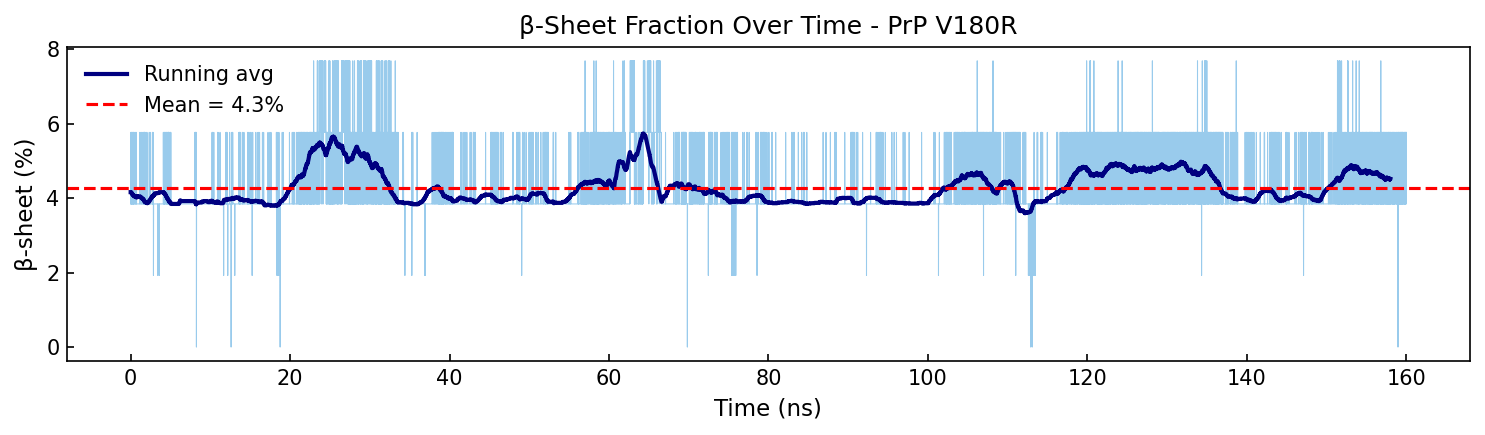

In [17]:
# ============================================================
# 5c. β-sheet content over time
# ============================================================
if dssp_available:
    sheet_t = S_oh[:, :, 2].mean(axis=1) * 100   # % per frame

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(time_ns, sheet_t, lw=0.5, alpha=0.5, color="#3498DB")
    w = min(200, len(sheet_t) // 5)
    if w > 1:
        savg = np.convolve(sheet_t, np.ones(w)/w, mode='valid')
        ax.plot(time_ns[:len(savg)], savg, lw=2, color="navy", label=f"Running avg")
    ax.axhline(sheet_t.mean(), ls="--", color="red", label=f"Mean = {sheet_t.mean():.1f}%")
    ax.set_xlabel("Time (ns)"); ax.set_ylabel("β-sheet (%)")
    ax.set_title(f"β-Sheet Fraction Over Time - PrP {MUTATION_NAME}"); ax.legend()
    plt.tight_layout(); plt.savefig(f"../figures/05c_beta_timeseries_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()


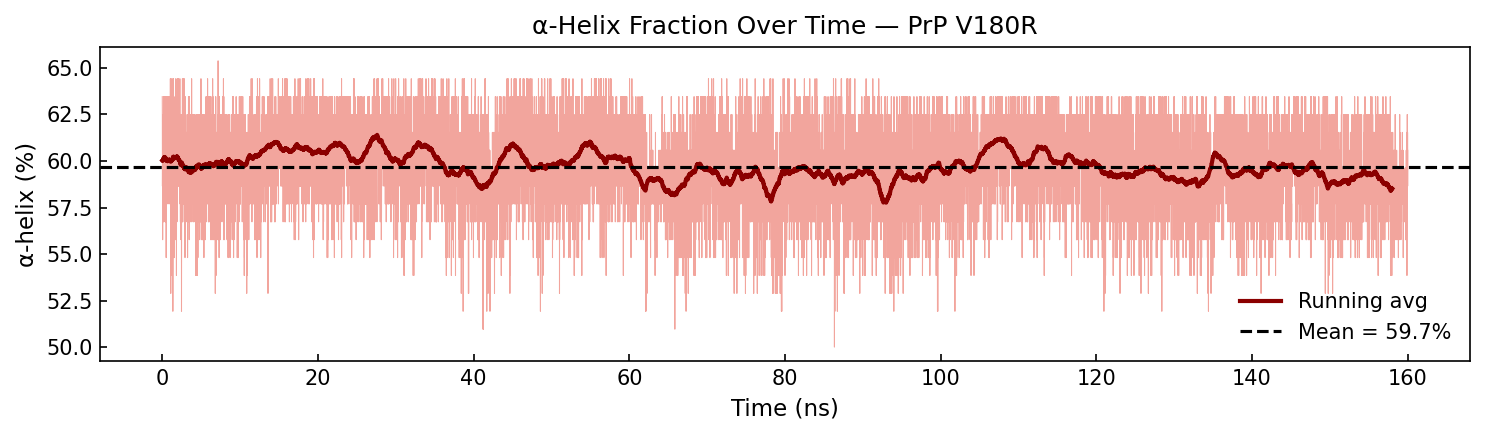

In [18]:
# ============================================================
# 5d. a-helices content over time
# ============================================================
if dssp_available:
    # ИЗМЕНЕНИЕ: Отслеживаем спирали (индекс 1), а не листы (индекс 2)
    helix_t = S_oh[:, :, 1].mean(axis=1) * 100   # % per frame

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(time_ns, helix_t, lw=0.5, alpha=0.5, color="#E74C3C")
    
    w = min(200, len(helix_t) // 5)
    if w > 1:
        savg = np.convolve(helix_t, np.ones(w)/w, mode='valid')
        ax.plot(time_ns[:len(savg)], savg, lw=2, color="darkred", label=f"Running avg")
        
    ax.axhline(helix_t.mean(), ls="--", color="black", label=f"Mean = {helix_t.mean():.1f}%")
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("α-helix (%)")
    ax.set_title(f"α-Helix Fraction Over Time — PrP {MUTATION_NAME}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"../figures/05d_helix_timeseries_{MUTATION_NAME.lower()}.png", dpi=300)
    plt.show()


---
## 6. Intramolecular Hydrogen Bonds

### ⚠️ Critical: Protein–Protein Only!

Secondary structures (helices and sheets) are physically held together by networks of intramolecular hydrogen bonds between the backbone amide ($N-H$) and carbonyl ($C=O$) groups.

### Why analyze H-Bonds?
While DSSP shows us the *macro-result* (e.g., "the helix melted"), the hydrogen bond analysis reveals the *micro-mechanism* (e.g., "the helix melted because the mutation broke three critical backbone bonds"). 

### Interpretation for Amyloid Breakers:
* **Total H-Bonds:** A global drop in the total number of intramolecular hydrogen bonds suggests overall destabilization.
* **Target Region Focus:** The real value lies in analyzing the H-bonds specifically within the target region (**170-193**). 
    * **Proline mutations (P):** Proline lacks an amide hydrogen ($N-H$). Therefore, inserting a Proline physically deletes a hydrogen bond donor, instantly creating a "hole" in the local H-bond network.
    * **Charged mutations (D, E, K, R):** These large side chains can cause steric clashes or unfavorable electrostatic repulsion that force the protein backbone to twist, indirectly stretching and breaking neighboring hydrogen bonds.
* **Success Metric:** A highly effective breaker mutation will show a persistently higher number of stable hydrogen bonds compared to the WT, corroborating the structural stability increase.

In [19]:
# ============================================================
# 6. INTRAMOLECULAR HYDROGEN BONDS
# ============================================================
hba = HBA(universe=u,
          between=["protein", "protein"],   
          donors_sel="name N O S",    # Hydrogen bond donors
          hydrogens_sel="name H*",    # Hydrogens
          acceptors_sel="name O N",   # Hydrogen bonds acceptors
          d_a_cutoff=3.5,                   
          d_h_a_angle_cutoff=150,           
          update_selections=False)

hba.run(verbose=True)

100%|████████████████████████████████████████████████████████████████████████████| 16001/16001 [00:43<00:00, 371.10it/s]


⟨Intramolecular H-bonds⟩ = 44.6 ± 3.6
Range: 29 – 56


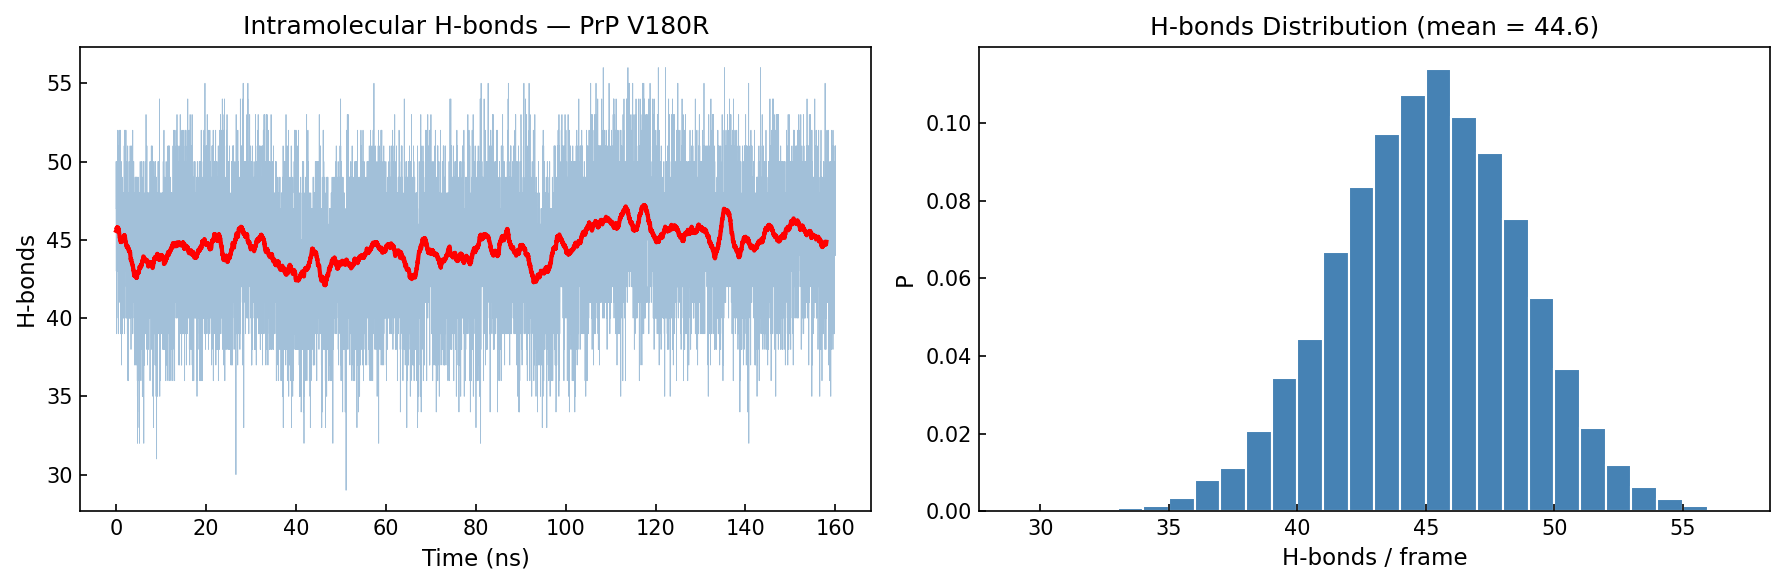

In [20]:
n_hb = hba.count_by_time()
print(f"⟨Intramolecular H-bonds⟩ = {n_hb.mean():.1f} ± {n_hb.std():.1f}")
print(f"Range: {n_hb.min()} – {n_hb.max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(time_ns, n_hb, lw=0.4, alpha=0.5, color="steelblue")
w = min(200, len(n_hb)//5)
if w > 1:
    havg = np.convolve(n_hb.astype(float), np.ones(w)/w, mode='valid')
    axes[0].plot(time_ns[:len(havg)], havg, lw=2, color="red")
axes[0].set_xlabel("Time (ns)"); axes[0].set_ylabel("H-bonds")
axes[0].set_title(f"Intramolecular H-bonds — PrP {MUTATION_NAME}")

axes[1].hist(n_hb, bins=range(int(n_hb.min()), int(n_hb.max())+2),
             density=True, color="steelblue", edgecolor="white")
axes[1].set_xlabel("H-bonds / frame"); axes[1].set_ylabel("P")
axes[1].set_title(f"H-bonds Distribution (mean = {n_hb.mean():.1f})")
plt.tight_layout(); plt.savefig(f"../figures/06_hbonds_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()


---
## 7. Disulfide Bond Monitoring (Cys179–Cys214)

The Cys179–Cys214 disulfide bond is the critical covalent staple holding Helix 2 (H2) and Helix 3 (H3) together. It serves as the primary structural anchor of the PrP C-terminal domain. 

* **Purpose:** Monitoring the distance between the sulfur atoms (SG–SG) helps assess local strain introduced by the mutation and verifies the topological integrity of the simulation.
* **Interpretation:** An intact, stable disulfide bond should rigidly maintain a distance of ~2.05 Å. While classical MD force fields typically restrain covalent bonds to prevent breaking, anomalous stretching or extreme fluctuations in this distance serve as a proxy for the structural stress. If a mutation in the amyloidogenic region generates enough thermodynamic force to pull H2 and H3 apart, it will manifest as sustained strain on this disulfide bridge.

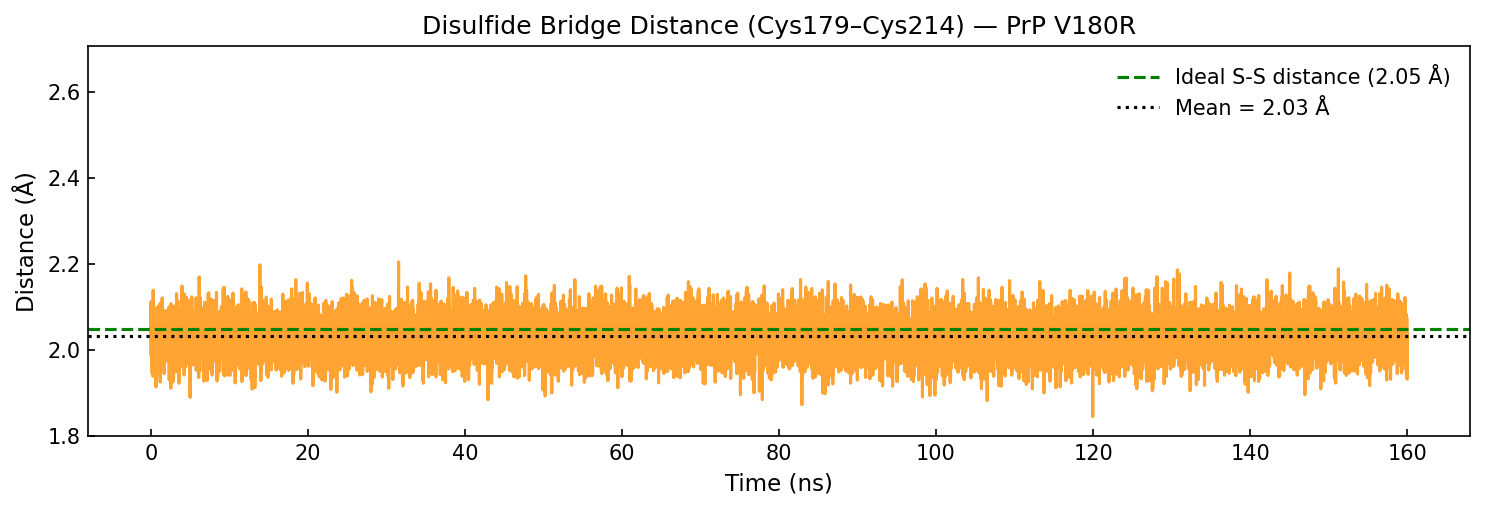

Cys179-Cys214 Average Distance: 2.033 ± 0.042 Å


In [21]:
# ============================================================
# 7. Disulfide Bond Monitoring (Cys179–Cys214)
# ============================================================
cys1 = u.select_atoms("resid 179 and name SG")
cys2 = u.select_atoms("resid 214 and name SG")

if len(cys1) == 0 or len(cys2) == 0:
    print("⚠️  Warning: SG atoms not found! Check atom names in your .gro file.")
else:
    ss_dist = np.empty(n_frames)

    for i, ts in enumerate(u.trajectory):
        ss_dist[i] = np.linalg.norm(cys1.positions[0] - cys2.positions[0])

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(time_ns, ss_dist, lw=1.5, color="darkorange", alpha=0.8)
    
    ax.axhline(2.05, ls="--", color="green", lw=1.5, label="Ideal S-S distance (2.05 Å)")
    ax.axhline(ss_dist.mean(), ls=":", color="black", label=f"Mean = {ss_dist.mean():.2f} Å")
    
    ax.set_ylim(max(1.8, ss_dist.min() - 0.5), min(ss_dist.max() + 0.5, 10.0))
    
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Distance (Å)")
    ax.set_title(f"Disulfide Bridge Distance (Cys179–Cys214) — PrP {MUTATION_NAME}")
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(f"../figures/07_disulfide_bond_{MUTATION_NAME.lower()}.png", dpi=300)
    plt.show()
    
    print(f"Cys179-Cys214 Average Distance: {ss_dist.mean():.3f} ± {ss_dist.std():.3f} Å")

---
## 8. Cα–Cα Contact Maps and H2–H3 Interface Analysis

A contact map provides a 2D matrix representation of the distances between all pairs of Cα atoms, acting as a structural fingerprint of the protein fold.

### Biological Context of the H2-H3 Interface
In the native Prion Protein, the interface between Helix 2 and Helix 3 forms a tightly packed hydrophobic core. The stability of this interface is widely considered a major barrier preventing the conformational rearrangement required for PrP^Sc amyloid formation.

### Interpretation:
1. **Global Contact Map:** The diagonal represents adjacent residues, while off-diagonal elements represent tertiary (long-range) contacts. A loss or weakening of off-diagonal clusters in the mutant compared to the WT indicates that the native fold is loosening.
2. **H2–H3 Interface Focus:** By zooming in on the contacts specifically between H2 and H3, we can determine if the "breaker" mutation is driving a wedge between these structural pillars. A decrease in contact frequency (or an increase in average distance) here strongly suggests that the mutation destabilizes the global fold, potentially increasing the mobility of the target 170-193 region.

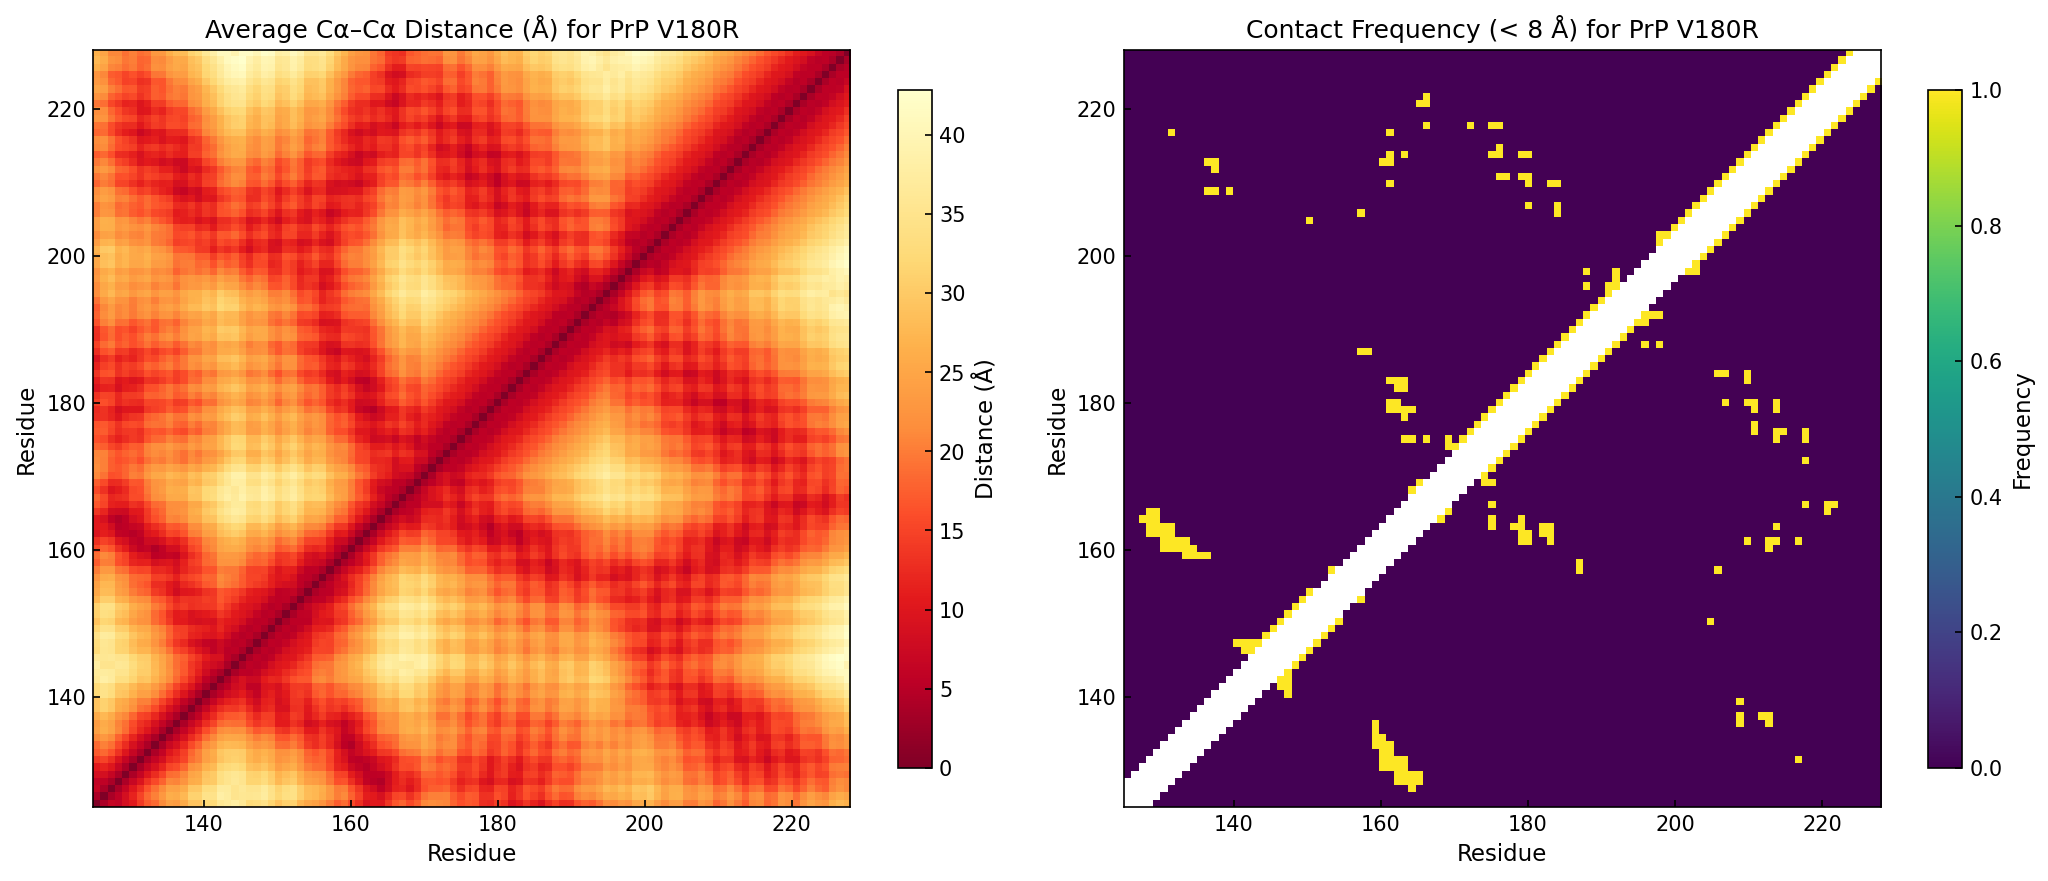

In [22]:
# ============================================================
# 8a. CONTACT MAP
# ============================================================
n_res = ca.n_residues
sum_dist = np.zeros((n_res, n_res))
sum_contact = np.zeros((n_res, n_res))
CONTACT_CUTOFF = 8.0   # Å; use 8.0 for PrP

for ts in u.trajectory:
    d = distances.distance_array(ca.positions, ca.positions, box=ts.dimensions)
    sum_dist += d
    sum_contact += (d < CONTACT_CUTOFF).astype(float)

avg_dist = sum_dist / n_frames
contact_freq = sum_contact / n_frames

# Mask trivial sequential contacts (|i-j| < 4)
seq_mask = np.abs(np.subtract.outer(np.arange(n_res), np.arange(n_res))) < 4

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(avg_dist, cmap="YlOrRd_r", origin="lower",
                      extent=[resids[0], resids[-1], resids[0], resids[-1]])
axes[0].set_title(f"Average Cα–Cα Distance (Å) for PrP {MUTATION_NAME}")
axes[0].set_xlabel("Residue"); axes[0].set_ylabel("Residue")
plt.colorbar(im1, ax=axes[0], label="Distance (Å)", shrink=0.8)

cf_plot = contact_freq.copy()
cf_plot[seq_mask] = np.nan
im2 = axes[1].imshow(cf_plot, cmap="viridis", origin="lower",
                      extent=[resids[0], resids[-1], resids[0], resids[-1]], vmin=0, vmax=1)
axes[1].set_title(f"Contact Frequency (< {CONTACT_CUTOFF:.0f} Å) for PrP {MUTATION_NAME}")
axes[1].set_xlabel("Residue"); axes[1].set_ylabel("Residue")
plt.colorbar(im2, ax=axes[1], label="Frequency", shrink=0.8)

plt.tight_layout(); plt.savefig(f"../figures/08a_contact_maps_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()


/tmp/ipykernel_3879/358614546.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


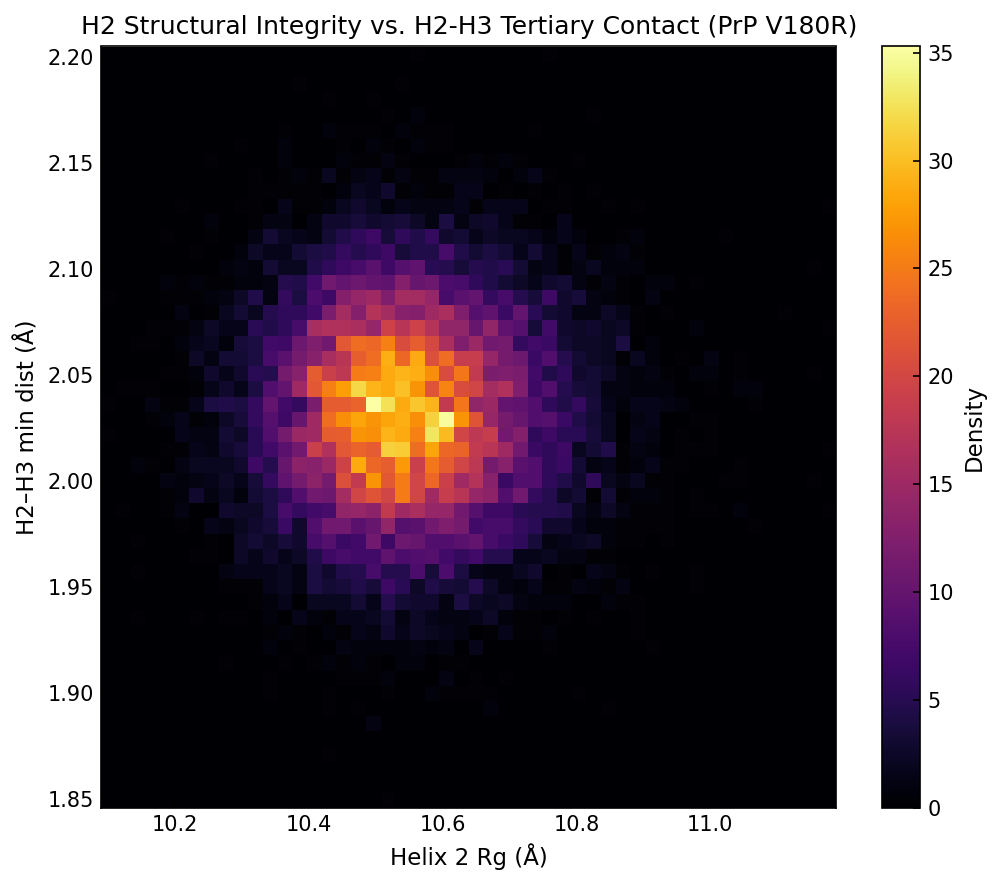

⟨H2 Rg⟩ = 10.55 Å | ⟨H2–H3 dist⟩ = 2.03 Å
Native-like fraction: 99.8%


In [23]:
# ============================================================
# 8b. Helix 2 - Helix 3 Interface Analysis
# ============================================================

from matplotlib.patches import Rectangle 

h2_sc = u.select_atoms("resid 173:194 and not name N CA C O H* HN HA")
h3_sc = u.select_atoms("resid 200:228 and not name N CA C O H* HN HA")

h2_rg = np.empty(n_frames)
h2_h3_d = np.empty(n_frames)

for i, ts in enumerate(u.trajectory):
    h2_rg[i] = h2_sc.radius_of_gyration()
    
    h2_h3_d[i] = distances.distance_array(
        h2_sc.positions, h3_sc.positions, box=ts.dimensions).min()
 
native = (h2_rg < 11.0) & (h2_h3_d < 4.5)
frac = native.mean() * 100

fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(h2_rg, h2_h3_d, bins=50, cmap="inferno", density=True)
plt.colorbar(h[3], ax=ax, label="Density")

ax.set_xlabel("Helix 2 Rg (Å)")
ax.set_ylabel("H2–H3 min dist (Å)")
ax.set_title(f"H2 Structural Integrity vs. H2-H3 Tertiary Contact (PrP {MUTATION_NAME})")
ax.legend()

plt.tight_layout()
plt.savefig(f"../figures/08b_h2_h3_analysis_{MUTATION_NAME.lower()}.png", dpi=300)
plt.show()

print(f"⟨H2 Rg⟩ = {h2_rg.mean():.2f} Å | ⟨H2–H3 dist⟩ = {h2_h3_d.mean():.2f} Å")
print(f"Native-like fraction: {frac:.1f}%")

---
## 9. Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique used to extract the "essential dynamics" of the protein—the largest, most dominant concerted motions occurring during the simulation, filtering out random thermal noise.

* **Why use PCA?** While RMSF shows *which* residues are flexible, PCA shows *how* they move together in 3D space.
* **Interpretation for PrP (2D Projections):** By plotting the trajectory onto the first two principal components (PC1 vs. PC2), we can visualize the conformational landscape. Each point represents a single simulation frame. 
    * **WT Baseline:** The Wild-Type should ideally sample a distinct, relatively compact conformational basin (a single dense cluster).
    * **Mutant Deviation:** If the mutant exhibits a widely scattered plot or shifts into entirely different basins, it indicates that the mutation has forced the protein out of its native energy minimum into new conformational states.
    * **Cosine content** - sign of model convergence over time

| Cosine content (PC1) | Meaning |
|---|---|
| < 0.2 | Good — likely converged |
| 0.2–0.5 | Marginal |
| > 0.5 | Poor — trajectory NOT converged (random diffusion) |

Time-ordered colour in the PC1–PC2 scatter = systematic drift = NOT converged.

Cosine content:
  PC1: 0.001  ✅
  PC2: 0.034  ✅
  PC3: 0.137  ✅


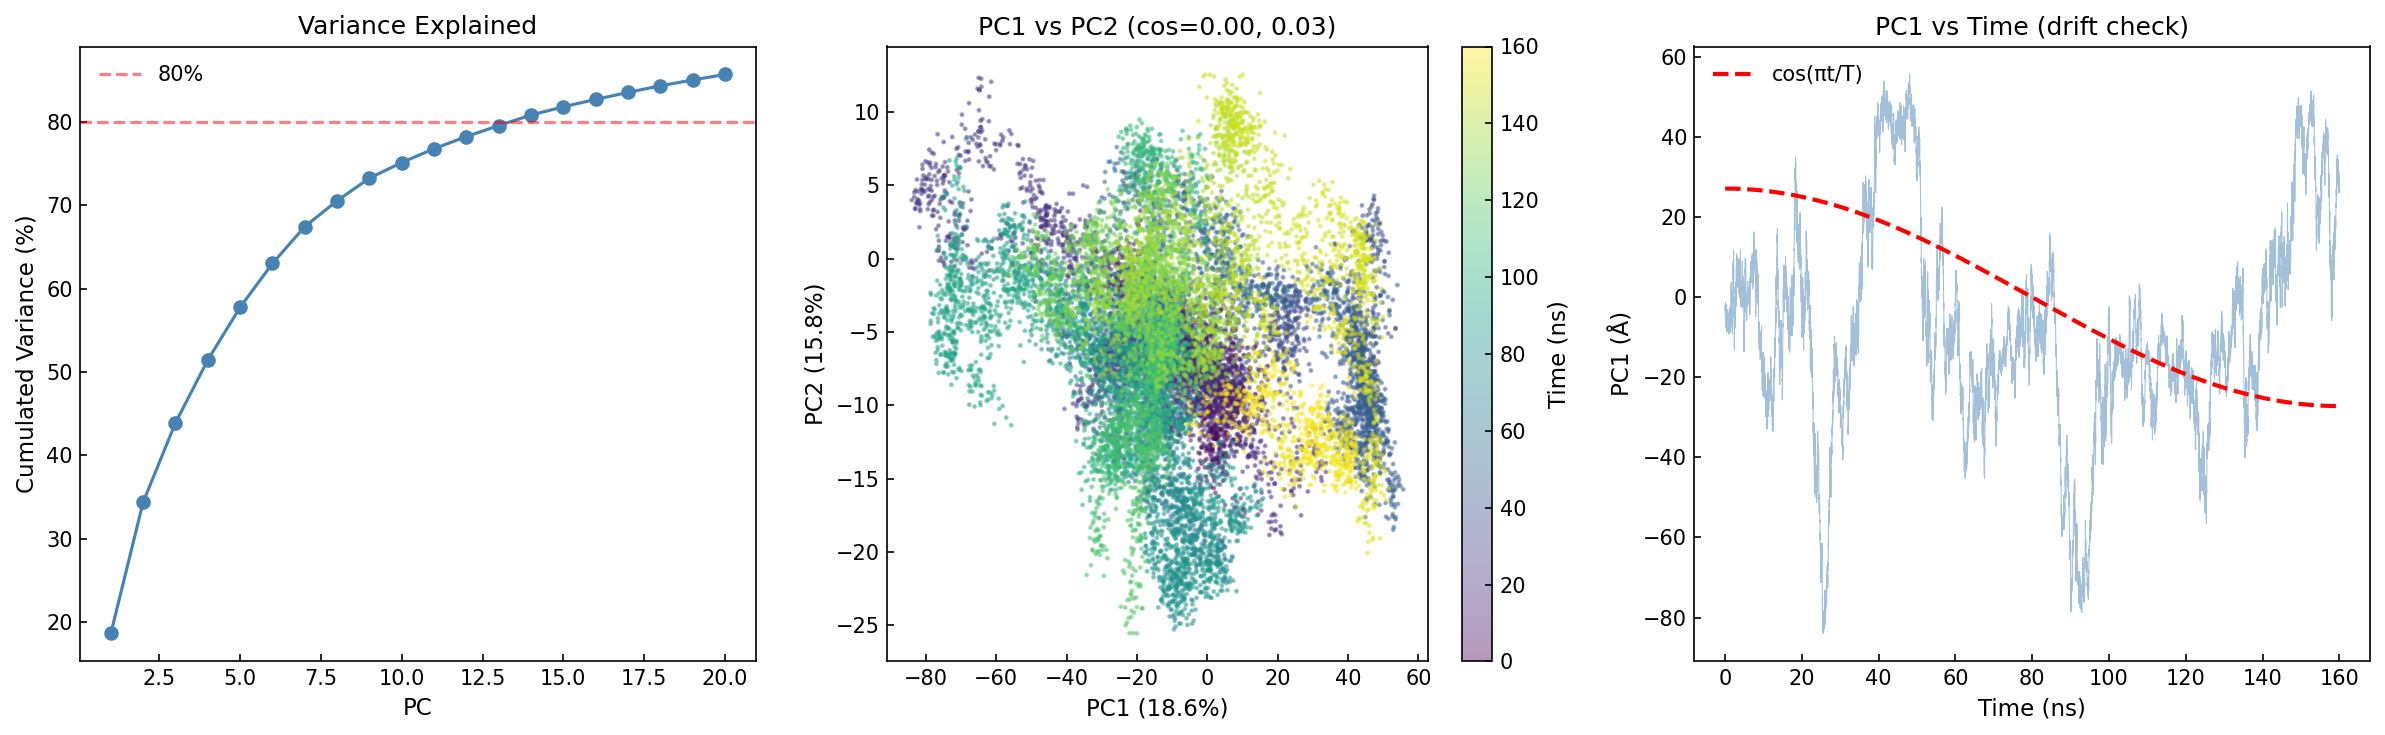

In [24]:
# ============================================================
# 9. PCA
# ============================================================
pc = pca.PCA(u, select="protein and name CA", align=True, mean=None).run()
cum_var = pc.results.cumulated_variance
proj = pc.transform(u.select_atoms("protein and name CA"), n_components=3)
cc = [pca.cosine_content(proj, i) for i in range(3)]

print("Cosine content:")
for i, c in enumerate(cc):
    tag = "✅" if c < 0.2 else ("⚠️" if c < 0.5 else "❌")
    print(f"  PC{i+1}: {c:.3f}  {tag}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cumulated variance
axes[0].plot(range(1, 21), cum_var[:20]*100, "o-", color="steelblue")
axes[0].axhline(80, ls="--", color="red", alpha=0.5, label="80%")
axes[0].set_xlabel("PC"); axes[0].set_ylabel("Cumulated Variance (%)")
axes[0].set_title("Variance Explained"); axes[0].legend()

# PC1 vs PC2
sc = axes[1].scatter(proj[:, 0], proj[:, 1], c=time_ns, cmap="viridis", s=2, alpha=0.4)
plt.colorbar(sc, ax=axes[1], label="Time (ns)")
axes[1].set_xlabel(f"PC1 ({pc.results.variance[0]/pc.results.variance.sum()*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pc.results.variance[1]/pc.results.variance.sum()*100:.1f}%)")
axes[1].set_title(f"PC1 vs PC2 (cos={cc[0]:.2f}, {cc[1]:.2f})")

# PC1 vs time + cosine overlay
axes[2].plot(time_ns, proj[:, 0], lw=0.5, alpha=0.5, color="steelblue")
t_norm = np.linspace(0, np.pi, n_frames)
axes[2].plot(time_ns, np.cos(t_norm)*np.std(proj[:, 0]), "r--", lw=2, label="cos(πt/T)")
axes[2].set_xlabel("Time (ns)"); axes[2].set_ylabel("PC1 (Å)")
axes[2].set_title("PC1 vs Time (drift check)"); axes[2].legend()

plt.tight_layout(); plt.savefig(f"../figures/10_pca_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()


---
## 10. Ramachandran Plot

The φ/ψ distribution reveals backbone conformational preferences. The Ramachandran plot visualizes the backbone dihedral angles (Φ and Ψ) of the protein residues, mapping the sterically allowed conformations of the polypeptide chain.

* **Global vs. Local:** While plotting the entire protein provides a general check of structural validity (most residues should stay in the α-helical basin for PrP), tracking specific regions might be more informative for our goals.
* **Interpretation for Amyloid Breakers:** By tracking the dihedral angles of the target region (170-193) or the specific mutated residue over time, we can observe its structural fate. 
    * Pathological conversion relies on sampling the **β-sheet basin** (typically the top-left quadrant). 
    * A successful **breaker mutation** (especially Proline, which has strictly constrained Φ angles) will physically force the backbone out of the β-sheet basin. If the mutant Ramachandran plot shows a clear shift away from β-sheet propensity compared to the WT, it supports the hypothesis that the mutation prevents cross-β amyloid formation.

/home/ser/miniforge3/envs/md_analysis/lib/python3.10/site-packages/MDAnalysis/analysis/dihedrals.py:444: UserWarning: Cannot determine phi and psi angles for the first or last residues
  warnings.warn(


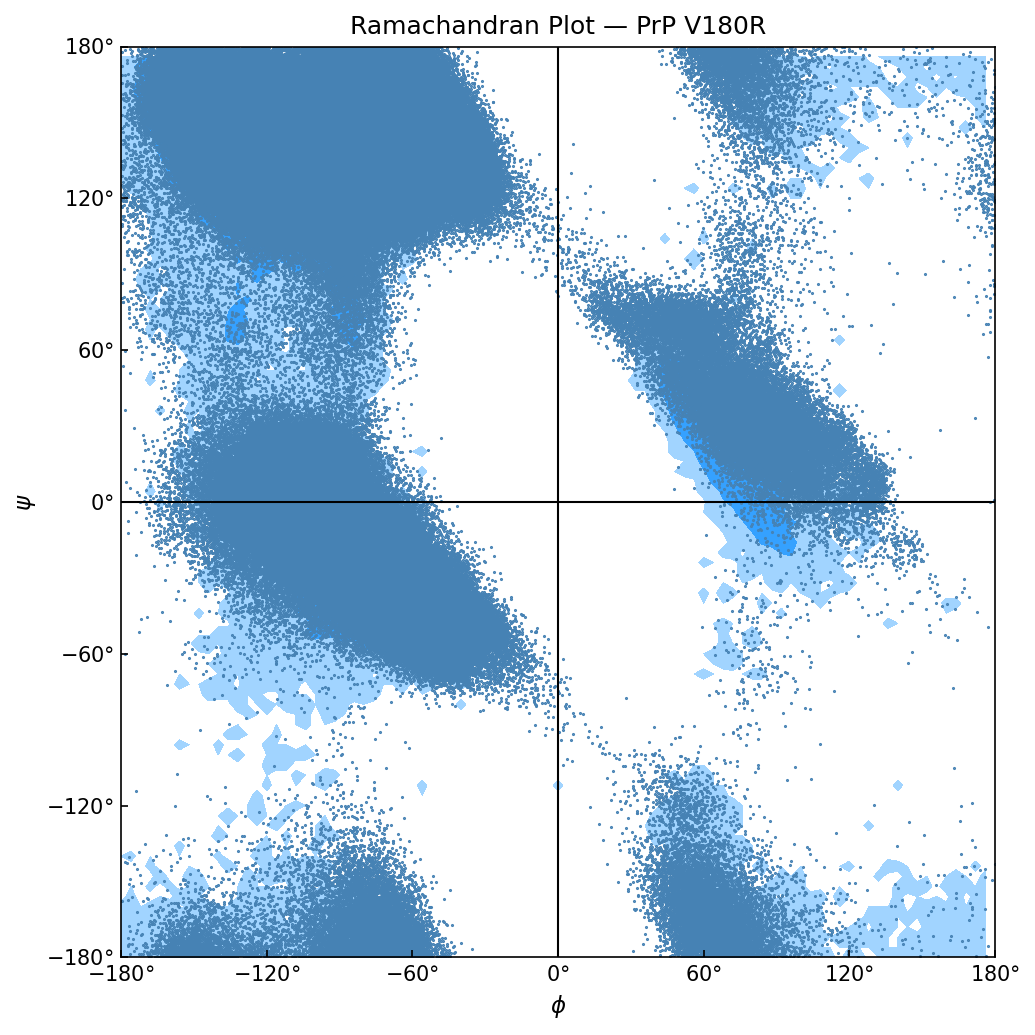

β: 25.7% | α: 59.4% | PPII: 9.0% | αL: 1.4%


In [25]:
# ============================================================
# 10. RAMACHANDRAN
# ============================================================
from MDAnalysis.analysis.dihedrals import Ramachandran
rama = Ramachandran(protein).run()

fig, ax = plt.subplots(figsize=(7, 7))

rama.plot(ax=ax, color="steelblue", marker=".", s=1, ref=True)
ax.set_title(f"Ramachandran Plot — PrP {MUTATION_NAME}")
plt.tight_layout()
plt.savefig(f"../figures/11_ramachandran_{MUTATION_NAME.lower()}.png", dpi=300)
plt.show()

# Quantify basin populations
phi_psi = rama.results.angles.reshape(-1, 2)
phi, psi = phi_psi[:, 0], phi_psi[:, 1]

beta  = ((phi < -50)  & (phi > -180) & (psi > 80)  & (psi < 180)).mean() * 100
alpha = ((phi < -40)  & (phi > -160) & (psi > -80) & (psi < -20)).mean() * 100
ppII  = ((phi < -50)  & (phi > -90)  & (psi > 110) & (psi < 170)).mean() * 100
aL    = ((phi > 30)   & (phi < 100)  & (psi > -10) & (psi < 80)).mean()  * 100

print(f"β: {beta:.1f}% | α: {alpha:.1f}% | PPII: {ppII:.1f}% | αL: {aL:.1f}%")


---
## 11. Convergence Assessment

A simulation can run to completion without crashing, yet still be completely unconverged. For a structured protein like PrP, convergence means the system has relaxed into a stable thermodynamic basin and is adequately sampling around that minimum, rather than continuously drifting.

### Why Convergence Matters for Amyloid Breakers
If a mutation destabilizes the native fold (e.g., melting Helix 2), we need to know if the unfolding event is *complete* within our simulation timeframe, or if we are only observing the very beginning of a massive, ongoing structural shift.

### Complementary Diagnostics:
1. **Block Averaging:** By calculating the standard error (SE) of structural observables (like $R_g$ or RMSD) across increasing block sizes, the SE should eventually plateau. A failure to plateau indicates long-timescale correlations (the structure is continuously drifting).
2. **Trajectory Halves Comparison (KS Test):** We split the trajectory into two halves (e.g., 0-80 ns and 80-160 ns) and compare the probability distributions of key metrics (like the SG-SG distance or target region RMSD). A high overlap (or a Kolmogorov-Smirnov test p-value > 0.05) suggests the sampling is converged.
3. **PCA Cosine Content:** As calculated in Section 9, the principal components of random diffusion closely resemble cosine functions. A cosine content close to 1.0 implies the protein is undergoing random structural drift (unconverged), while a value < 0.7 suggests converged sampling within a discrete energy basin.
4. **Autocorrelation Time:** Evaluates how quickly the structure changes its previous conformation, providing the effective number of independent structural samples ($N_{eff}$) generated by the simulation.

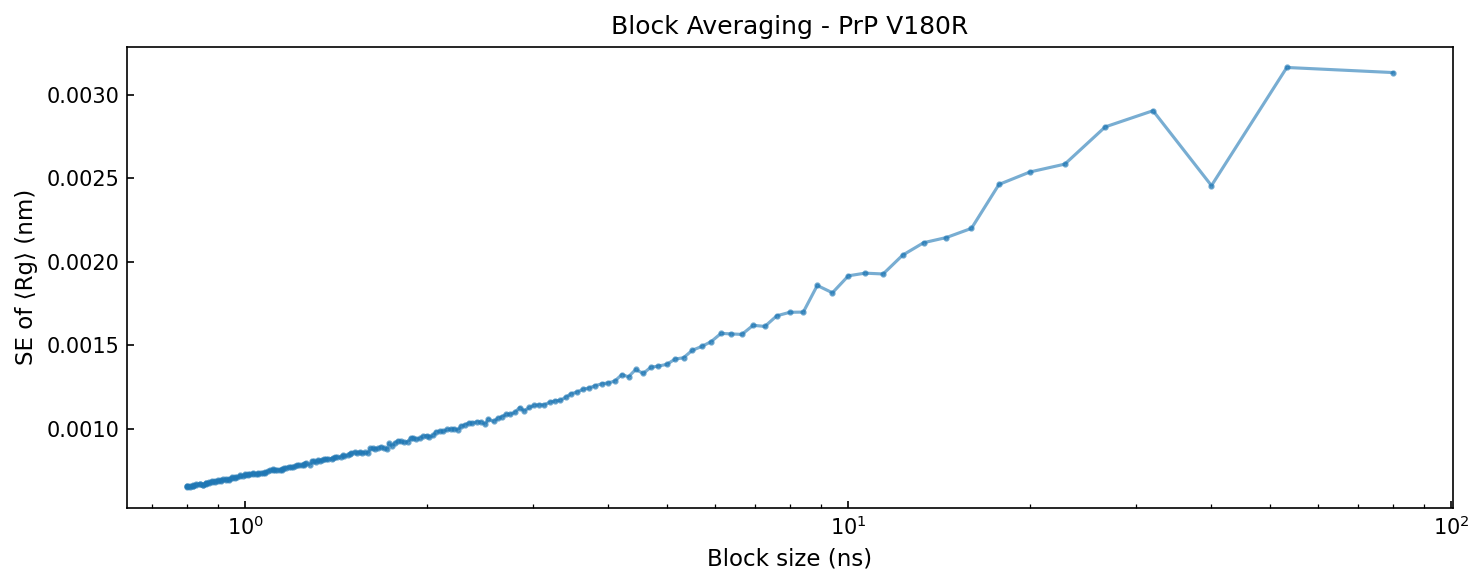

In [26]:
# ============================================================
# 11a. BLOCK AVERAGING
# ============================================================
def block_average_se(x, max_blocks=200):
    x = np.asarray(x, dtype=float); N = len(x)
    sizes, ses = [], []
    for nb in range(max_blocks, 1, -1):
        bs = N // nb
        if bs < 2: continue
        means = x[:nb*bs].reshape(nb, bs).mean(axis=1)
        sizes.append(bs); ses.append(means.std(ddof=1) / np.sqrt(nb))
    return np.array(sizes), np.array(ses)

bsize, se_rg = block_average_se(rg_nm)
bsize_ns = bsize * dt_ps / 1000

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(bsize_ns, se_rg, "o-", markersize=2, alpha=0.6)
ax.set_xlabel("Block size (ns)"); ax.set_ylabel("SE of ⟨Rg⟩ (nm)")
ax.set_title(f"Block Averaging - PrP {MUTATION_NAME}")
plt.tight_layout(); plt.savefig(f"../figures/12a_block_averaging_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()


/tmp/ipykernel_3879/770884331.py:26: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"../figures/12b_ks_test_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()
/home/ser/miniforge3/envs/md_analysis/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


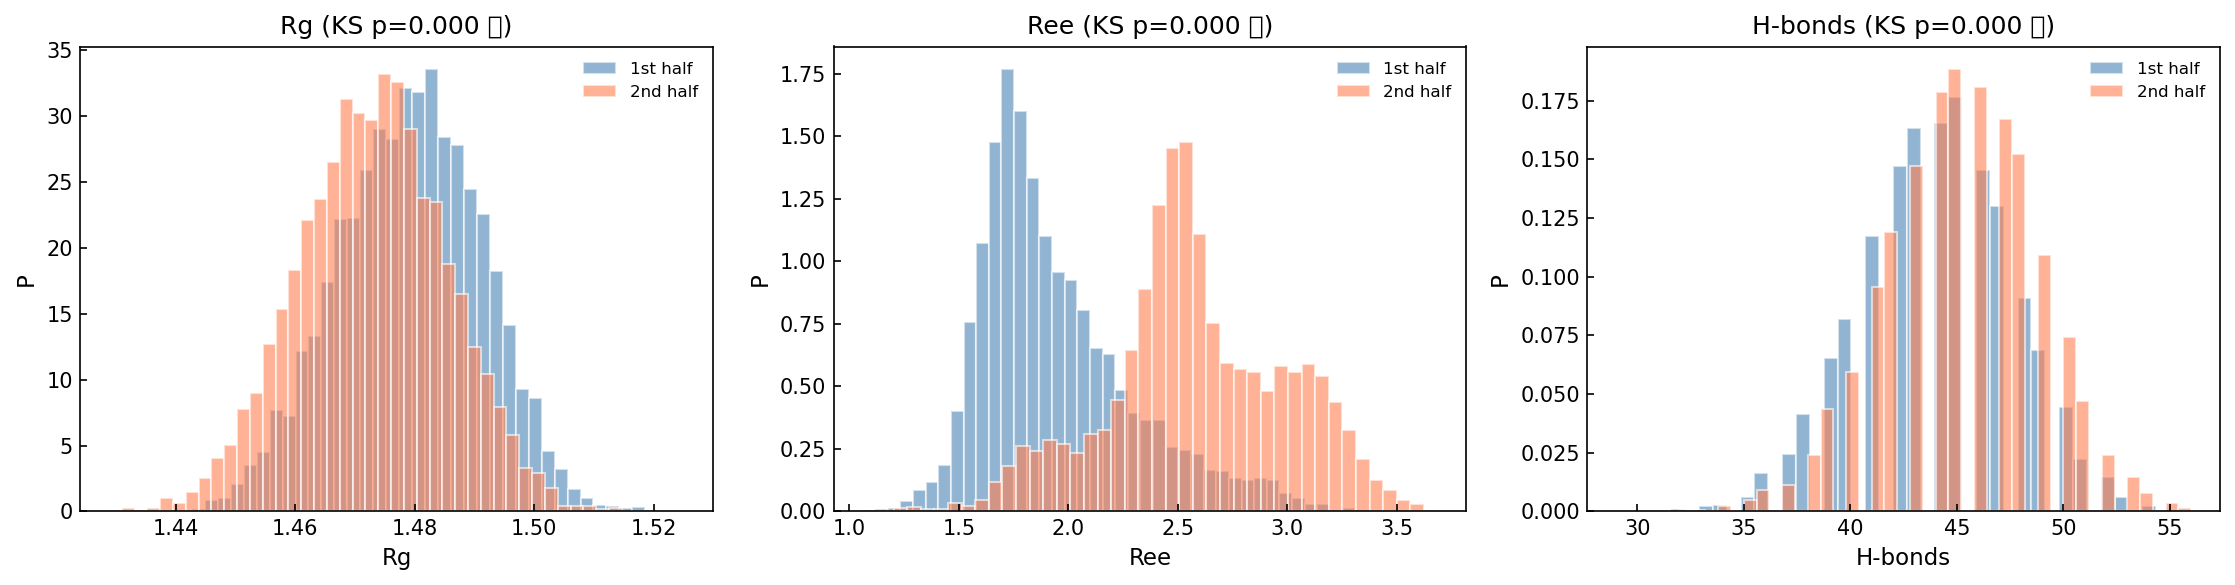

KS(Rg): D=0.2099, p=0.0000  ❌
KS(Ree): D=0.6541, p=0.0000  ❌
KS(H-bonds): D=0.1274, p=0.0000  ❌


In [27]:
# ============================================================
# 11b. HALF-TRAJECTORY KS TEST
# ============================================================
half = n_frames // 2
tests = [
    ("Rg",      rg_nm),
    ("Ree",     ree_nm),
    ("H-bonds", n_hb.astype(float)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
results_list = []

for ax, (name, data) in zip(axes, tests):
    ks, p = stats.ks_2samp(data[:half], data[half:])
    status = "✅" if p > 0.05 else "❌"
    results_list.append((name, ks, p, status))

    ax.hist(data[:half], bins=40, density=True, alpha=0.6,
            color="steelblue", label="1st half", edgecolor="white")
    ax.hist(data[half:], bins=40, density=True, alpha=0.6,
            color="coral", label="2nd half", edgecolor="white")
    ax.set_title(f"{name} (KS p={p:.3f} {status})")
    ax.set_xlabel(name); ax.set_ylabel("P"); ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig(f"../figures/12b_ks_test_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()

for name, ks, p, st in results_list:
    print(f"KS({name}): D={ks:.4f}, p={p:.4f}  {st}")


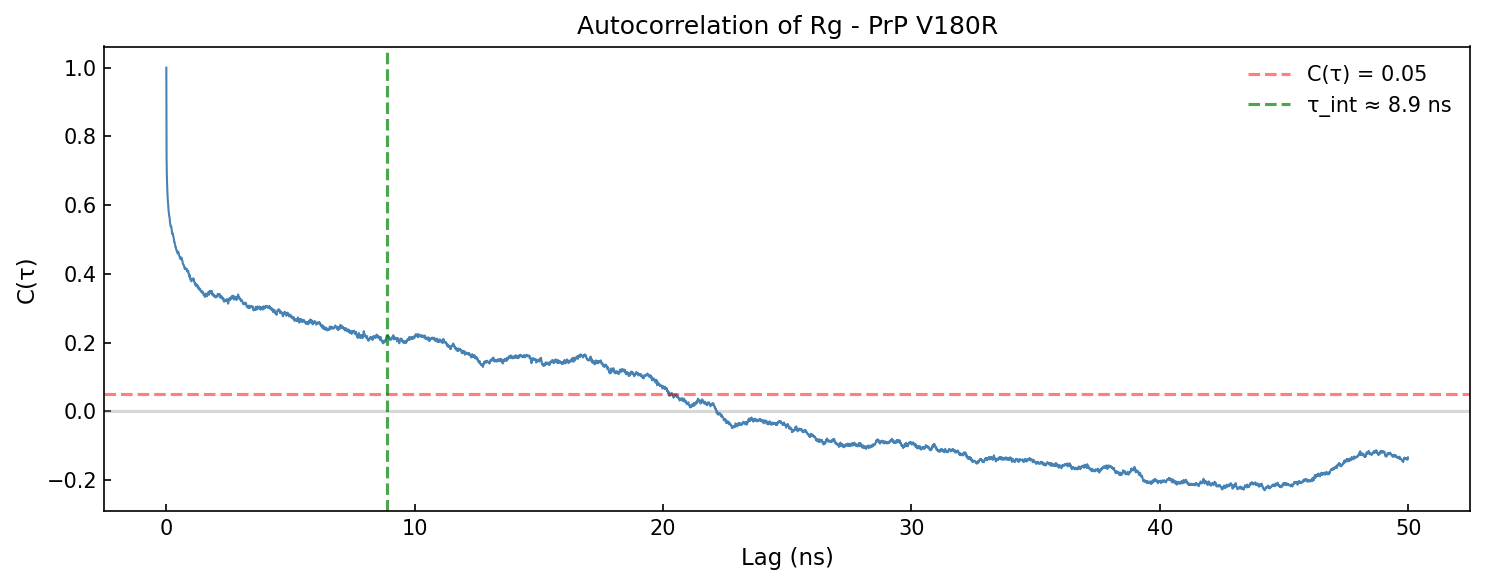

τ_int(Rg) ≈ 8.9 ns | N_eff ≈ 18


In [28]:
# ============================================================
# 11c. AUTOCORRELATION TIME
# ============================================================
def autocorrelation(x):
    x = x - x.mean()
    result = correlate(x, x, mode="full")
    result = result[len(x)-1:]
    return result / result[0]

ac_rg = autocorrelation(rg_nm)
cutoff_idx = np.argmax(ac_rg < 0.05)
if cutoff_idx == 0: cutoff_idx = len(ac_rg) // 2
tau_int = 1 + 2 * np.sum(ac_rg[1:cutoff_idx])
tau_ns = tau_int * dt_ps / 1000
N_eff = n_frames / max(tau_int, 1)

max_lag = int(min(total_ns/2, 50) * 1000 / dt_ps)
lag_ns = np.arange(max_lag) * dt_ps / 1000

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lag_ns, ac_rg[:max_lag], lw=1, color="steelblue")
ax.axhline(0, ls="-", color="gray", alpha=0.3)
ax.axhline(0.05, ls="--", color="red", alpha=0.5, label="C(τ) = 0.05")
ax.axvline(tau_ns, ls="--", color="green", alpha=0.7, label=f"τ_int ≈ {tau_ns:.1f} ns")
ax.set_xlabel("Lag (ns)"); ax.set_ylabel("C(τ)")
ax.set_title(f"Autocorrelation of Rg - PrP {MUTATION_NAME}"); ax.legend()
plt.tight_layout(); plt.savefig(f"../figures/12c_autocorrelation_{MUTATION_NAME.lower()}.png", dpi=300); plt.show()

print(f"τ_int(Rg) ≈ {tau_ns:.1f} ns | N_eff ≈ {N_eff:.0f}")


In [29]:
# ============================================================
# 11d. CONVERGENCE SUMMARY TABLE
# ============================================================
# Collect all diagnostics
last_q = se_rg[int(0.75*len(se_rg)):] if len(se_rg) >= 10 else se_rg
cv = last_q.std() / last_q.mean() if len(last_q) > 1 else 999

summary = pd.DataFrame({
    "Diagnostic": [
        "Block-avg SE plateau (CV < 0.1)",
        "KS Rg (p > 0.05)",
        "KS Ree (p > 0.05)",
        "KS H-bonds (p > 0.05)",
        "PC1 cosine content (< 0.2)",
        "τ_int / T_total (< 0.1)",
        "N_eff (≥ 50)"
    ],
    "Value": [
        f"CV = {cv:.3f}",
        f"p = {results_list[0][2]:.4f}",
        f"p = {results_list[1][2]:.4f}",
        f"p = {results_list[2][2]:.4f}",
        f"{cc[0]:.3f}",
        f"{tau_ns / total_ns:.3f}",
        f"{N_eff:.0f}"
    ],
    "Pass?": [
        "✅" if cv < 0.1 else "❌",
        "✅" if results_list[0][2] > 0.05 else "❌",
        "✅" if results_list[1][2] > 0.05 else "❌",
        "✅" if results_list[2][2] > 0.05 else "❌",
        "✅" if cc[0] < 0.2 else ("⚠️" if cc[0] < 0.5 else "❌"),
        "✅" if (tau_ns / total_ns) < 0.1 else "❌",
        "✅" if N_eff >= 50 else "❌"
    ]
})

print("\n" + "=" * 60)
print("       CONVERGENCE ASSESSMENT SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))
print("=" * 60)
n_pass = summary["Pass?"].str.contains("✅").sum()
print(f"\n{n_pass}/{len(summary)} passed.")
if n_pass < len(summary):
    print("⚠️  Consider extending the simulation or running additional replicas.")



       CONVERGENCE ASSESSMENT SUMMARY
                     Diagnostic      Value Pass?
Block-avg SE plateau (CV < 0.1) CV = 0.316     ❌
               KS Rg (p > 0.05) p = 0.0000     ❌
              KS Ree (p > 0.05) p = 0.0000     ❌
          KS H-bonds (p > 0.05) p = 0.0000     ❌
     PC1 cosine content (< 0.2)      0.001     ✅
        τ_int / T_total (< 0.1)      0.055     ✅
                   N_eff (≥ 50)         18     ❌

2/7 passed.
⚠️  Consider extending the simulation or running additional replicas.


---
## 12. Publication-Quality Summary Figure


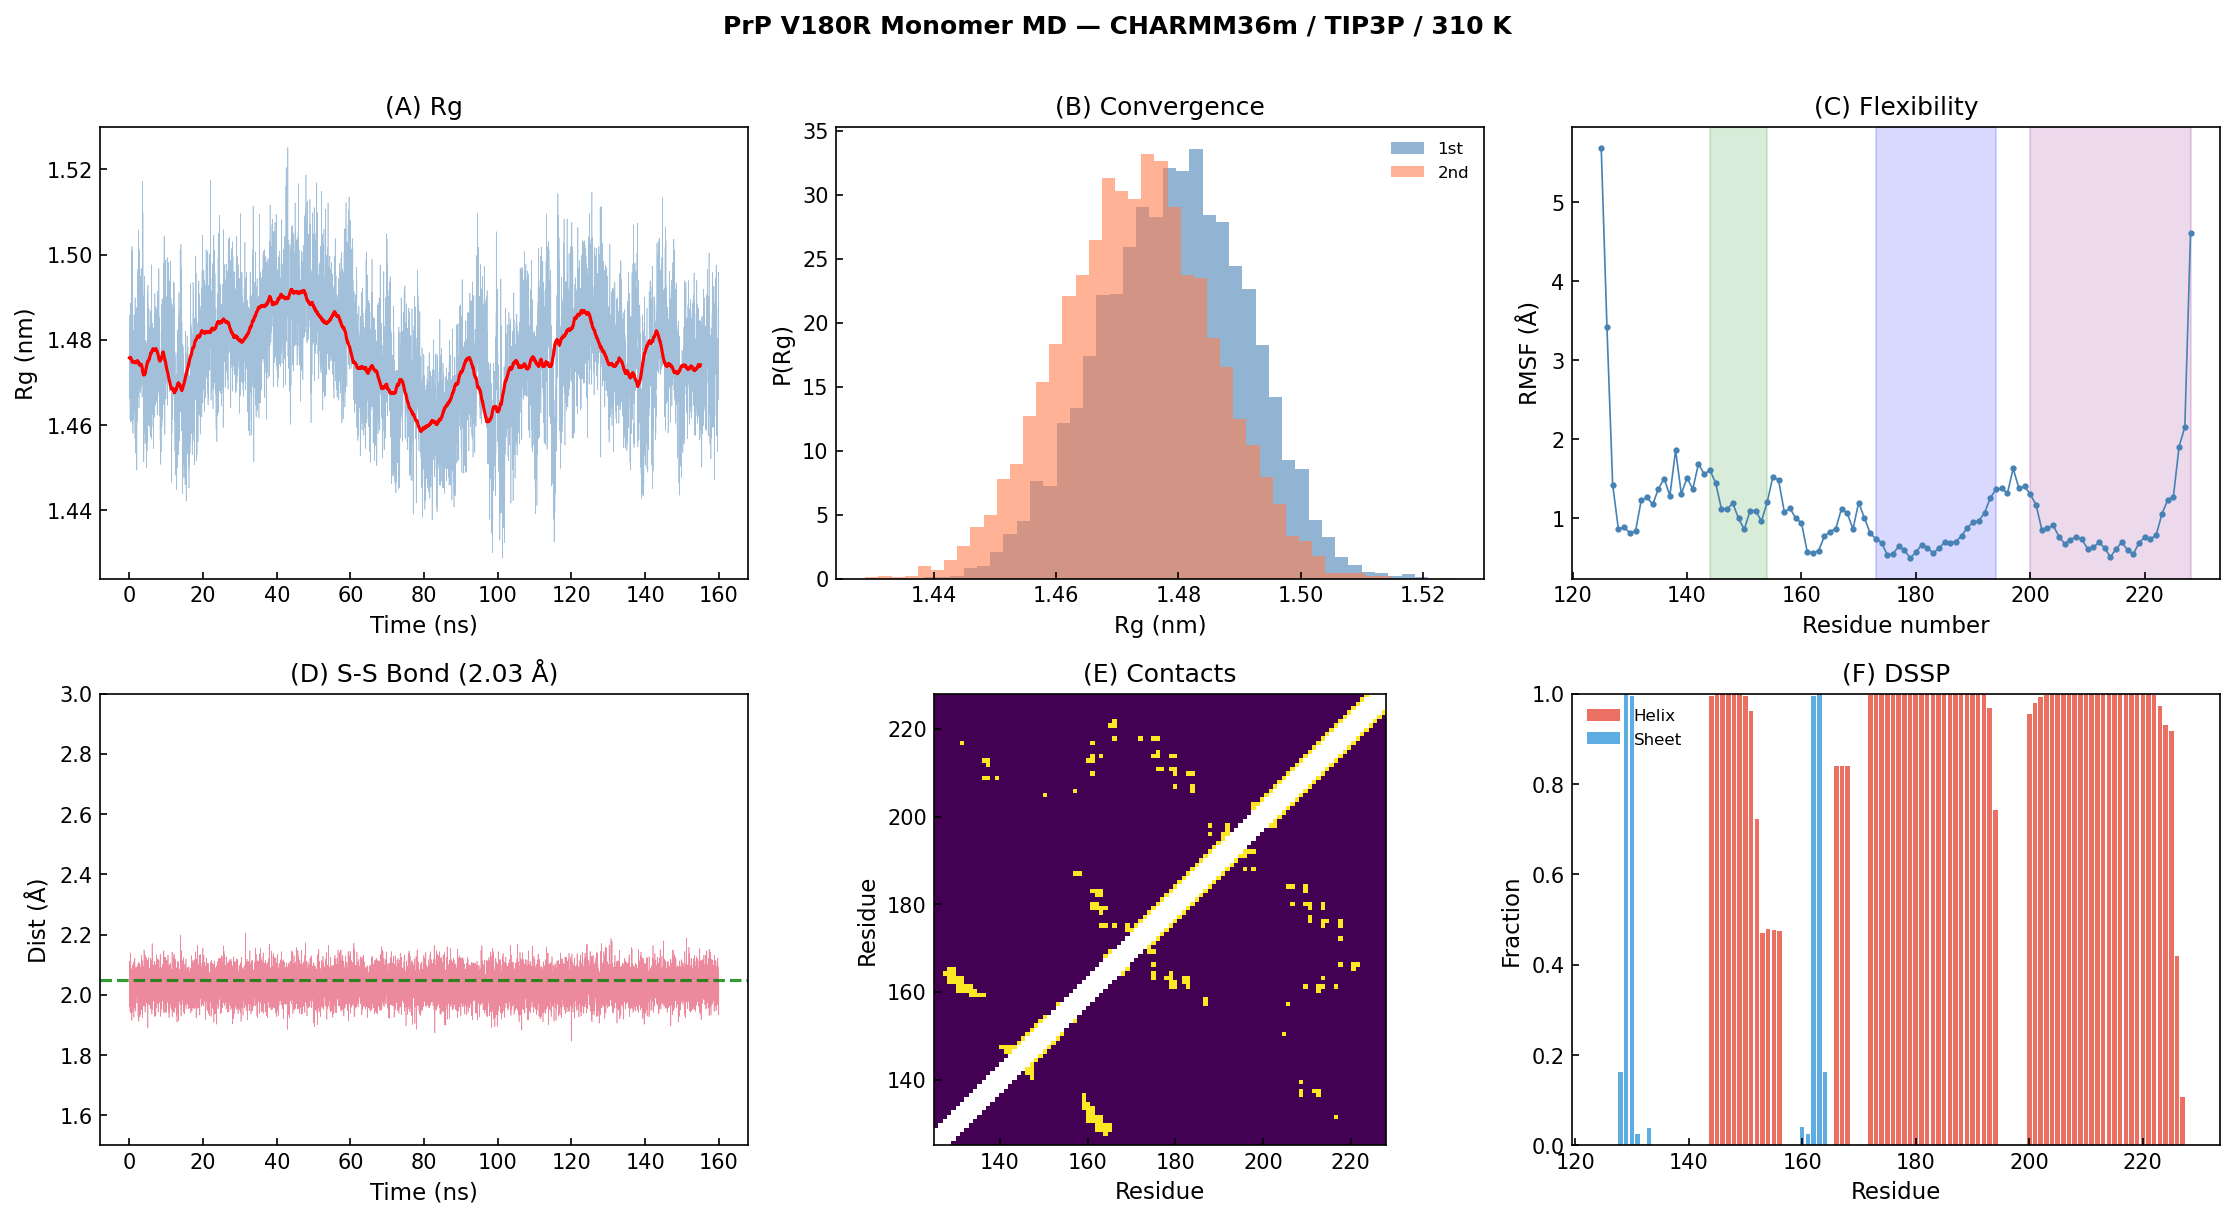

✅ Summary saved as PNG (600 dpi) and PDF (vector)


In [30]:
# ============================================================
# 12. MULTI-PANEL SUMMARY FIGURE
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"PrP {MUTATION_NAME} Monomer MD — CHARMM36m / TIP3P / 310 K", fontsize=12, fontweight="bold", y=1.01)

# (A) Rg time series
ax = axes[0, 0]
ax.plot(time_ns, rg_nm, lw=0.3, alpha=0.5, color="steelblue")
w = min(500, n_frames//5)
if w > 1:
    ax.plot(time_ns[:len(np.convolve(rg_nm, np.ones(w)/w, mode='valid'))],
            np.convolve(rg_nm, np.ones(w)/w, mode='valid'), lw=1.5, color="red")
ax.set_xlabel("Time (ns)"); ax.set_ylabel("Rg (nm)"); ax.set_title("(A) Rg")

# (B) Rg distribution halves
ax = axes[0, 1]
ax.hist(rg_nm[:half], bins=40, density=True, alpha=0.6, color="steelblue", label="1st")
ax.hist(rg_nm[half:], bins=40, density=True, alpha=0.6, color="coral", label="2nd")
ax.set_xlabel("Rg (nm)"); ax.set_ylabel("P(Rg)"); ax.set_title("(B) Convergence"); ax.legend(fontsize=8)

# (C) RMSF
ax = axes[0, 2]
ax.plot(resids, rmsf_A, "o-", color="steelblue", markersize=2, lw=0.8)
ax.axvspan(144, 154, alpha=0.15, color="green", label="H1")
ax.axvspan(173, 194, alpha=0.15, color="blue", label="H2")
ax.axvspan(200, 228, alpha=0.15, color="purple", label="H3")
ax.set_xlabel("Residue number"); ax.set_ylabel("RMSF (Å)"); ax.set_title("(C) Flexibility")

# (D) Cys179-Cys214 (Disulfide Bond)
ax = axes[1, 0]
ax.plot(time_ns, ss_dist, lw=0.3, alpha=0.5, color="crimson")
ax.axhline(2.05, ls="--", color="green", lw=1.5, alpha=0.8, label="Ideal S-S (2.05 Å)")
ax.set_ylim(1.5, max(3.0, ss_dist.max() + 0.5)) 
ax.set_xlabel("Time (ns)"); ax.set_ylabel("Dist (Å)"); ax.set_title(f"(D) S-S Bond ({ss_dist.mean():.2f} Å)")

# (E) Contact map
ax = axes[1, 1]
cf_p = contact_freq.copy(); cf_p[seq_mask] = np.nan
ax.imshow(cf_p, cmap="viridis", origin="lower",
          extent=[resids[0], resids[-1], resids[0], resids[-1]], vmin=0, vmax=0.8)
ax.set_xlabel("Residue"); ax.set_ylabel("Residue"); ax.set_title("(E) Contacts")

# (F) Secondary structure
ax = axes[1, 2]
if dssp_available:
    ax.bar(resids_dssp, helix_per_res, color="#E74C3C", alpha=0.8, label="Helix")
    ax.bar(resids_dssp, sheet_per_res, bottom=helix_per_res, color="#3498DB", alpha=0.8, label="Sheet")
    ax.set_xlabel("Residue"); ax.set_ylabel("Fraction"); ax.set_title("(F) DSSP"); ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "DSSP N/A", transform=ax.transAxes, ha="center")

plt.tight_layout()
plt.savefig(f"../figures/13_summary_{MUTATION_NAME.lower()}.png", dpi=600, bbox_inches="tight")
plt.savefig(f"../figures/13_summary_{MUTATION_NAME.lower()}.pdf", bbox_inches="tight")
plt.show()
print("✅ Summary saved as PNG (600 dpi) and PDF (vector)")


---
## Summary and Next Steps

In this notebook, we successfully validated and analyzed the Molecular Dynamics trajectory of the Prion Protein (PrP). By correcting the structural numbering to match biological standards, we accurately targeted the critical amyloidogenic region (**residues 170-193**).

### Key Takeaways:
* **Global Stability:** RMSD, RMSF, and $R_g$ metrics provided a macroscopic view of the protein's integrity, revealing whether the C-terminal domain remained folded or experienced pathological expansion.
* **Mechanism of Action:** DSSP and Intramolecular Hydrogen Bond analyses offered an atomic-resolution explanation of the mutation's effect. For "breaker" mutations, these tools are vital to confirm if the sequence's ability to maintain rigid, amyloid-prone conformations has been successfully disrupted.
* **Structural Interfaces:** Contact maps and disulfide bond monitoring ensured that we caught any long-range structural consequences of the point mutation propagating through the H2-H3 core.

### Next Steps in the Pipeline:
1. **Comparative Analysis:** Run this identical notebook for the Wild-Type (WT) and other high-priority mutant candidates (e.g., V180R). 
2. **Quantitative Extraction:** Extract the average values from the converged portions of these trajectories (e.g., mean number of H-bonds or % of helical content lost).
3. **Integrative Scoring:** Feed these dynamic structural metrics back into the consensus analysis pipeline (alongside PASTA 2.0, TANGO, etc.) to definitively rank the most potent amyloidogenic breakers. 
4. **Sampling Limits:** If the convergence assessment (Section 11) indicates continuous drift, consider running replicate simulations with different random velocity seeds or extending the simulation time to thoroughly sample the protein's slow structural drifts.


*Bioinformatics Institute, St. Petersburg — Spring 2026*